# Notebook for setting up and prcoessing the RHINO calibration Gibbs Sampler

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sampler.reader import ObservationReader, ReflectionReader

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams.update({
    "font.family": "serif"
})

## Set up observation and reflections

In [2]:
observation = ObservationReader('simulated_data/sim_data.hdf5')
print(np.unique(observation.states_array))

reflection_dict = {'antenna':'simulated_data/antenna_gamma_src.s2p',
                   'heated_load':"simulated_data/heated_load_gamma_src.s2p",
                   'internal_load':'simulated_data/internal_load_gamma_src.s2p',
                   'long_open':'simulated_data/long_open_gamma_src.s2p',
                   'long_short':'simulated_data/long_short_gamma_src.s2p',
                   'open':'simulated_data/open_gamma_src.s2p',
                   'short':'simulated_data/short_gamma_src.s2p',
                   'receiver':'simulated_data/gamma_rec.s2p',
                   'noise_diode':'simulated_data/noise_diode_gamma_src.s2p'}

reflections = ReflectionReader(component_dict=reflection_dict,
                               output_frequencies=observation.freqs,
                               polynomial_interp=True,
                               polynomial_fitting_order=10)

Calculated... delta_nu: 39062.5, delta_t: 5.0
['antenna' 'heated_load' 'internal_load' 'long_open' 'long_short' 'open'
 'short']


/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:158: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:158: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:158: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:158: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:158: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:158: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:158: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampl

# Check Observation

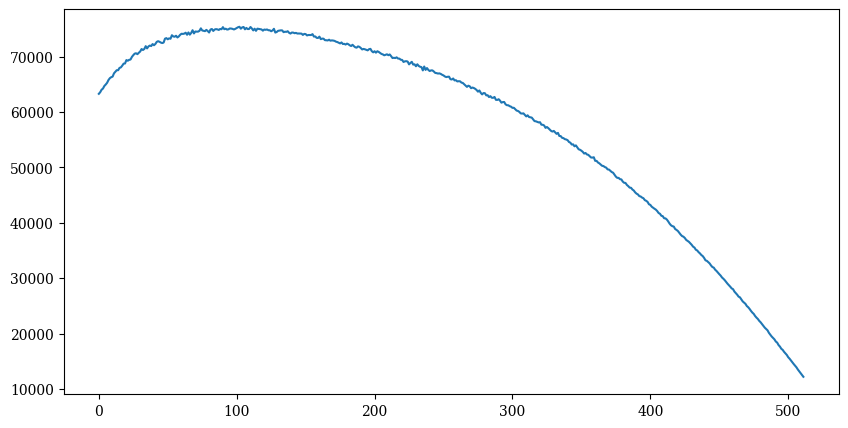

In [3]:
plt.plot(observation.data_waterfall[100])
plt.show()

# RFI Flag

In [4]:
from MomentRFI.MomentRFI import IterativeSurfaceFitter
from rfi_flagging.rfi_flagging import mask_by_state


## Set up basis functions

In [5]:
from sampler.linear_basis import BasisConstructor

In [6]:
# gains_basis = BasisConstructor(observation.times,
#                                observation.freqs,
#                                n_time_modes=1,
#                                n_freq_modes=5,
#                                basis_function='polynomial',
#                                time_norm=1*(observation.times[-1] - observation.times[0]),
#                                frequency_norm=np.median(observation.freqs),
#                                zero_time=True)

gains_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=5,
                               basis_function='fourier',
                               time_norm=4*(observation.times[-1] - observation.times[0]),
                               frequency_norm=4*(observation.freqs[-1] - observation.freqs[0]),
                               zero_time=True)

unc_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=1*(observation.times[-1] - observation.times[0]),
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

# unc_basis = BasisConstructor(observation.times,
#                                observation.freqs,
#                                n_time_modes=1,
#                                n_freq_modes=4,
#                                basis_function='fourier',
#                                time_norm=4*(observation.times[-1] - observation.times[0]),
#                                frequency_norm=4*(observation.freqs[-1] - observation.freqs[0]),
#                                zero_time=True)

cos_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=1*(observation.times[-1] - observation.times[0]),
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

# cos_basis = BasisConstructor(observation.times,
#                                observation.freqs,
#                                n_time_modes=1,
#                                n_freq_modes=4,
#                                basis_function='fourier',
#                                time_norm=4*(observation.times[-1] - observation.times[0]),
#                                frequency_norm=4*(observation.freqs[-1] - observation.freqs[0]),
#                                zero_time=True)

sin_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=1*(observation.times[-1] - observation.times[0]),
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

# sin_basis = BasisConstructor(observation.times,
#                                observation.freqs,
#                                n_time_modes=1,
#                                n_freq_modes=4,
#                                basis_function='fourier',
#                                time_norm=4*(observation.times[-1] - observation.times[0]),
#                                frequency_norm=4*(observation.freqs[-1] - observation.freqs[0]),
#                                zero_time=True)

rx_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=1*(observation.times[-1] - observation.times[0]),
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

# rx_basis = BasisConstructor(observation.times,
#                                observation.freqs,
#                                n_time_modes=1,
#                                n_freq_modes=4,
#                                basis_function='fourier',
#                                time_norm=4*(observation.times[-1] - observation.times[0]),
#                                frequency_norm=4*(observation.freqs[-1] - observation.freqs[0]),
#                                zero_time=True)

noise_diode_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=1*(observation.times[-1] - observation.times[0]),
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

# cal temperature set up: give the same time orders
cal_n_time_modes = 1


ambient_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=cal_n_time_modes,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=1*(observation.times[-1] - observation.times[0]),
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

ambient_basis_y = BasisConstructor(observation.times,
                               0,
                               n_time_modes=cal_n_time_modes,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=1*(observation.times[-1] - observation.times[0]),
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

heated_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=cal_n_time_modes,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=1*(observation.times[-1] - observation.times[0]),
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

heated_basis_y = BasisConstructor(observation.times,
                               0,
                               n_time_modes=cal_n_time_modes,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=1*(observation.times[-1] - observation.times[0]),
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)
####

antenna_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=1*(observation.times[-1] - observation.times[0]),
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

## Construct Operators

In [7]:
from sampler.operator_setup import generate_noise_wave_transfer_matrix
from sampler.operator_setup import generate_non_smooth_source_matrix, generate_smooth_source_matrix, generate_noise_wave_transfer_matrix
# Noise Wave Operator
X_noise_wave, nw_slice_dict = generate_noise_wave_transfer_matrix(observation,
                                                               reflections,
                                                               unc_basis,
                                                               cos_basis,
                                                               sin_basis,
                                                               rx_basis)
print(nw_slice_dict)
print(X_noise_wave.shape)


{'unc': slice(0, 1, None), 'cos': slice(1, 2, None), 'sin': slice(2, 3, None), 'rx': slice(3, 4, None)}
(368640, 4)


## Construct Antenna Operator

In [8]:
X_antenna = generate_smooth_source_matrix(observation,
                                          reflections,
                                          source_basis=antenna_basis,
                                          source_label='antenna')

# X_noise_diode = generate_smooth_source_matrix(observation,
#                                           reflections,
#                                           source_basis=noise_diode_basis,
#                                           source_label='noise_diode')

print(X_antenna.shape)

(368640, 1)


### Combine Noisewave and Antenna Operators

In [9]:
from sampler.operator_setup import concat_and_index_operators

X_ant_noisewave = np.concatenate((X_antenna, X_noise_wave), axis=1)

X_ant_noisewave, ant_noise_wave_slice_dict = concat_and_index_operators([X_antenna,
                                                                         #X_noise_diode,
                                                                         X_noise_wave],
                                                                         label_list=['antenna',
                                                                                     #'noise_diode',
                                                                                     'noise_wave'])

print(ant_noise_wave_slice_dict)

{'antenna': slice(0, 1, None), 'noise_wave': slice(1, 5, None)}


## Construct Calibration Source Operator

In [10]:
print(np.unique(observation.switch_states))

['antenna' 'heated_load' 'internal_load' 'long_open' 'long_short' 'open'
 'short']


In [11]:
X_ambient = generate_smooth_source_matrix(observation, reflections,
                                          source_basis=ambient_basis,
                                          source_label=['internal_load', 'long_open',
                                                        'long_short', 'open', 'short'])
X_heated = generate_smooth_source_matrix(observation, reflections,
                                         source_basis=heated_basis,
                                         source_label='heated_load')

X_calibrator, calibrator_slice_dict = concat_and_index_operators([X_ambient,
                                                                  X_heated],
                                                                  ['ambient',
                                                                   'heated'])


from sampler.priors import generate_smooth_thermistor_operator_matrix

Y_ambient = generate_smooth_thermistor_operator_matrix(observation,
                                          source_basis=ambient_basis_y,
                                          source_label=['internal_load', 'long_open',
                                                        'long_short', 'open', 'short'])


Y_heated = generate_smooth_thermistor_operator_matrix(observation,
                                         source_basis=heated_basis_y,
                                         source_label='heated_load')

Y_calibrator, calibrator_slice_dict_y = concat_and_index_operators([Y_ambient,
                                                                  Y_heated],
                                                                  ['ambient',
                                                                   'heated'])

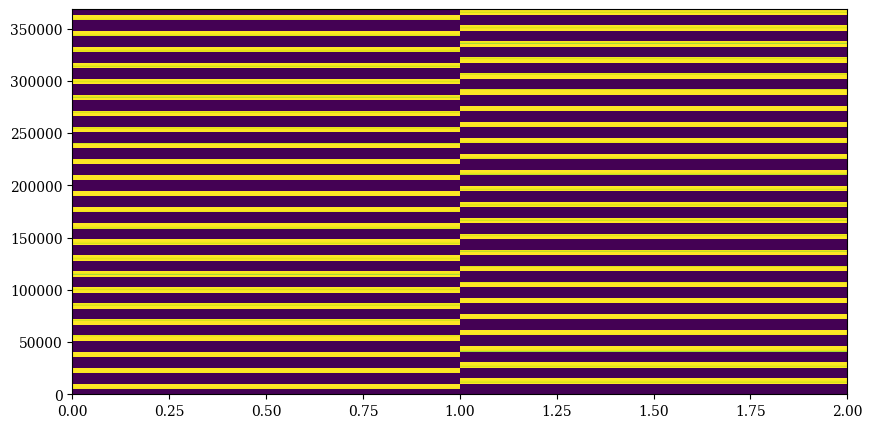

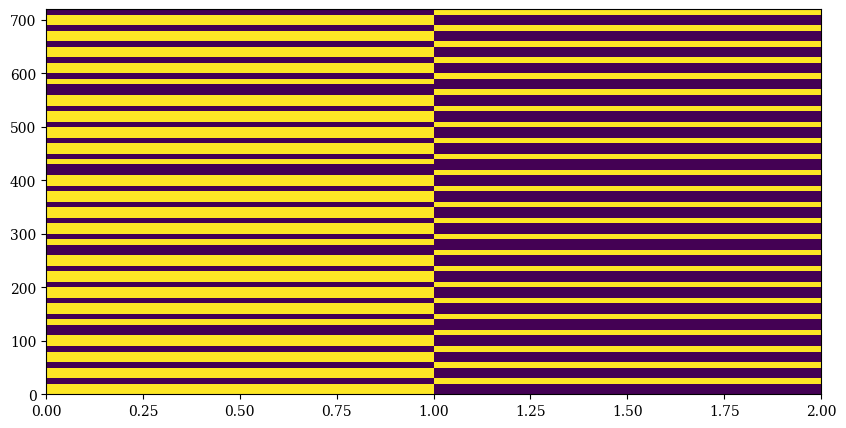

{'ambient': slice(0, 1, None), 'heated': slice(1, 2, None)}


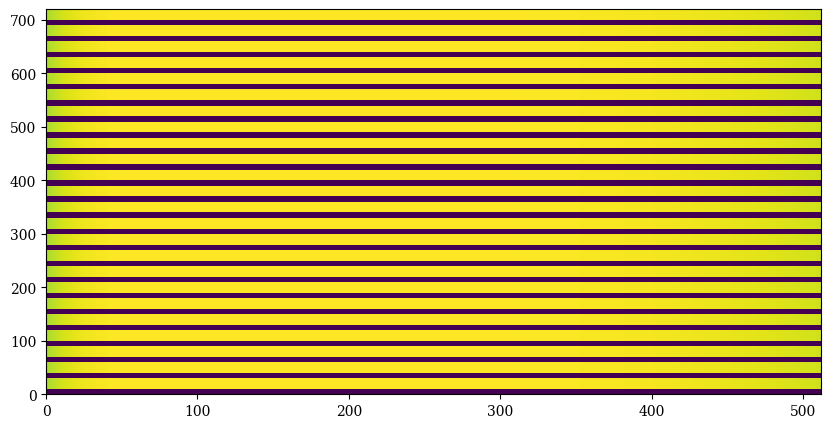

In [12]:

plt.pcolormesh(X_calibrator)
plt.show()

plt.pcolormesh(Y_calibrator)
plt.show()

print(calibrator_slice_dict)

cont = X_calibrator @ np.ones_like(X_calibrator[0])
cont = np.reshape(cont, shape=observation.data_waterfall.shape)
plt.pcolormesh(cont)
plt.show()

In [13]:
print(np.unique(observation.switch_states))

['antenna' 'heated_load' 'internal_load' 'long_open' 'long_short' 'open'
 'short']


### Construct Cal Source Priors

In [14]:
from sampler.priors import setup_probe_cal_priors
cal_source_priors, cal_source_prior_inv_cov = setup_probe_cal_priors(observation,
                                           source_temp_dict={'heated':'heated_load',
                                                             'ambient':['internal_load',
                                                                        'open',
                                                                        'short',
                                                                        'long_open',
                                                                        'long_short']},
                                                                        temp_std=1)


In [15]:
### Attempt a Weiner solution fit

from sampler.gibbs_sample import construct_gcr_lhs, construct_gcr_rhs, solve_gcr



cal_source_lhs = construct_gcr_lhs(linear_operator=Y_calibrator,
                                   inv_data_cov=cal_source_prior_inv_cov,
                                   inv_prior_cov=None,)
cal_source_rhs = construct_gcr_rhs(linear_operator=Y_calibrator,
                                   data=cal_source_priors,
                                   inv_data_cov=cal_source_prior_inv_cov,
                                   omega_data=np.zeros_like(cal_source_priors),
                                   priors=None,
                                   inv_prior_cov=None,
                                   weiner_solution=True,)

init_calibrator_solution = solve_gcr(cal_source_lhs, cal_source_rhs,linalg_init=False,
                                     atol=1e-10, rtol=1e-12, maxiter=int(1e6))


print(init_calibrator_solution)


# ambient_amps, heated_amps = init_calibrator_solution[:4], init_calibrator_solution[4:]
# print(ambient_amps)
# print(heated_amps)

# reconstructed_ambient = ambient_basis.basis_matrix @ ambient_amps
# reconstructed_heated = ambient_basis.basis_matrix @ heated_amps

# plt.pcolormesh(np.reshape(reconstructed_ambient, shape=observation.data_waterfall.shape))
# plt.colorbar()
# plt.show()

# plt.pcolormesh(np.reshape(reconstructed_heated, shape=observation.data_waterfall.shape))
# plt.colorbar()
# plt.show()

[292.99950027 442.99915213]


In [16]:
# cal_source_priors = np.array([np.mean(observation.temperatures['ambient']),
#                                      np.mean(observation.temperatures['heated'])])
# cal_source_prior_inv_cov = np.ones_like(cal_source_priors) * (1 / 0.0005)

print(cal_source_prior_inv_cov)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.

In [17]:
## Construct cal source priors from raw temperatures

## Gain Operator

In [18]:
U_gain = gains_basis.basis_matrix
print(U_gain.shape)
# plt.pcolormesh(U_gain)
# plt.show()

(368640, 10)


In [19]:
print(observation.temperatures)

{'heated': array([443.00728629, 442.99250525, 443.00602418, 443.00914312,
       442.99353989, 443.01325227, 442.99509656, 443.00103262,
       442.99546949, 443.01169359, 442.99248421, 442.98083397,
       443.00761442, 442.99717552, 442.99504398, 443.0113698 ,
       443.00527016, 443.01884008, 442.99549579, 442.99710246,
       442.99943097, 442.98446367, 442.99518403, 442.99271386,
       443.00993205, 443.01126131, 442.99487926, 443.0103323 ,
       443.01235417, 442.9987707 , 443.00811735, 442.98963654,
       442.98713967, 443.00862642, 442.9970026 , 442.99233128,
       442.98889237, 442.99049206, 442.99794252, 442.99560343,
       442.99234552, 443.0034649 , 443.00940511, 443.00932376,
       443.00396204, 442.98691806, 443.00093939, 442.99339432,
       442.9862408 , 443.03186961, 443.00636857, 443.00121244,
       442.99203928, 442.9857422 , 442.98824803, 443.00798391,
       443.00468449, 443.01211393, 442.99126723, 443.00192133,
       443.00111585, 443.02290443, 442.98877

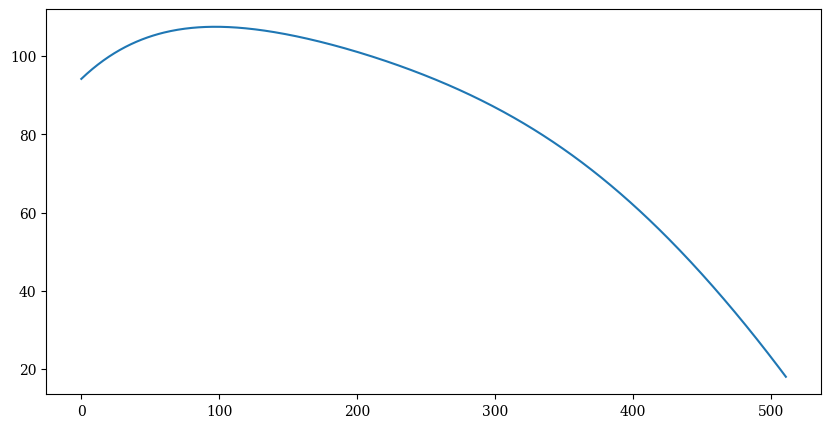

In [20]:
# get an initial guess of the gains params

def init_gain_guess(observation_obj: ObservationReader,
                    reflections_obj: ReflectionReader,
                    gains_basis: BasisConstructor,
                    noise_source_label: str = "heated_load",
                    load_label: str = 'internal_load',
                    noise_source_temp: int | None = None):

    noise_source_mask = (observation_obj.states_array == noise_source_label)
    load_mask = (observation_obj.states_array == load_label)
    p_ns = observation_obj.data_waterfall[noise_source_mask].mean(axis=0)
    p_l = observation_obj.data_waterfall[load_mask].mean(axis=0)

    if noise_source_temp is not None: t_ns = noise_source_temp
    else:
        t_ns = np.mean(observation_obj.temperatures['heated'])
    t_l = np.mean(observation_obj.temperatures['ambient'])

    gamma_rec = reflections_obj.s11_dict['receiver']

    mean_gain = (p_ns - p_l) / ((t_ns - t_l) * (1 - np.power(np.abs(gamma_rec), 2)))

    fitting_gain = np.zeros_like(observation.data_waterfall)
    fitting_gain[:,:] = mean_gain
    fitting_gain = fitting_gain.flatten()
    init_amp_guess = np.linalg.lstsq(gains_basis.basis_matrix, fitting_gain)[0]

    return init_amp_guess


# def gain_correction(observation_obj: ObservationReader,
#                     reflections_obj: ReflectionReader,
#                     noise_source_label: str = "heated_load",
#                     load_label: str = 'internal_load',
#                     polynomial_order: int,
#                     noise_source_temp: int | None = None,):
    
#     noise_source_mask = (observation_obj.states_array == noise_source_label)
#     load_mask = (observation_obj.states_array == load_label)
#     p_ns = observation_obj.data_waterfall[noise_source_mask].mean(axis=0)
#     p_l = observation_obj.data_waterfall[load_mask].mean(axis=0)
    


init_gain_amps = init_gain_guess(observation, reflections, gains_basis)

recov_init_gains = gains_basis.basis_matrix @ init_gain_amps
recov_init_gains = np.reshape(recov_init_gains,
                              shape=observation.data_waterfall.shape)

plt.plot(np.mean(recov_init_gains, axis=0))

# Set up Gibbs Sampler

In [21]:
from sampler.gibbs_sample import sample_loop

In [22]:
print(init_calibrator_solution)

[292.99950027 442.99915213]


In [23]:
param_dict = sample_loop(data=observation.data_waterfall.flatten(),
                         N=observation.Nw.flatten(),
                         U_gain=U_gain,
                         X_ant_nw=X_ant_noisewave,
                         X_cal_src=X_calibrator,
                         init_gain_amps=init_gain_amps,
                         init_cal_src_amps=init_calibrator_solution,
                         init_ant_nw_amps=np.ones_like(X_ant_noisewave[0]),
                         cal_src_priors=cal_source_priors,
                         inv_cal_src_prior_cov=cal_source_prior_inv_cov, n_iter=500,
                         fix_cal_source=False,
                         Y_cal_src=Y_calibrator,
                         verbose=True,
                         chi_square_stats=True)

d_cont  [652.04890493 653.72608667 662.89306114 ... 406.32729035 407.74564176
 407.12846594]
inv_cont_cov  [0.85586293 0.80795086 0.76361626 ... 0.9268451  0.92900016 0.93125697]
p_ant_nw - 0
[2600.03390356  303.27697244   50.63883348   57.8211282   406.81468197]
d_gain  [95.51031267 95.15906453 95.89397299 ... 18.88157162 18.4450167
 17.96068594]
d_gain_inv_cov  [ 21.49320816  21.36814007  21.24607193 ... 545.39254468 573.66703116
 604.27886505]
p_gain - 0
[-281.99191958  446.50342586 -200.30216046   54.70288532   -0.93070828
    0.         -241.26844747  117.08614799  -63.31952723   10.7460099 ]
d_cont  [ 1.58166417e+00 -2.74162489e+00  3.37681394e-01 ...  4.07981628e+02
  4.08966847e+02  4.07887717e+02]
inv_cont_cov  [0.47258317 0.46337061 0.45442883 ... 1.03724924 1.03741317 1.03758425]
p_cal_src - 0
[292.98343541 442.98898575]
chi_sq:  26855158181.482407
Gibbs Sample - 0 / 500
d_cont  [644.24975708 646.31734628 655.78426747 ... 406.69184114 408.20687286
 407.68060309]
inv_cont_cov

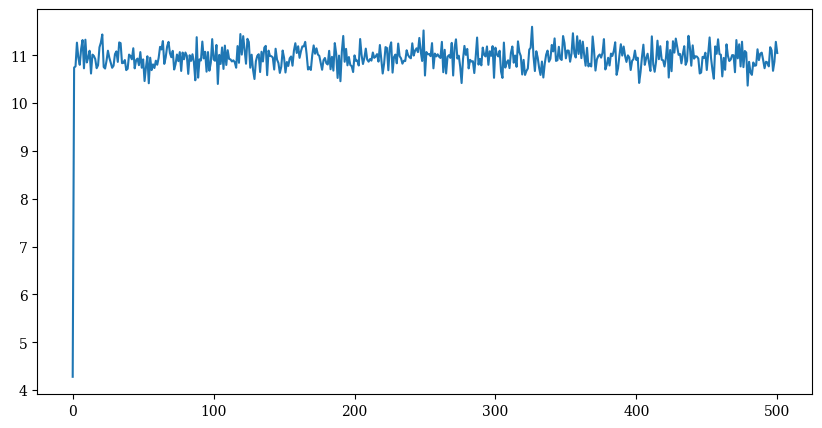

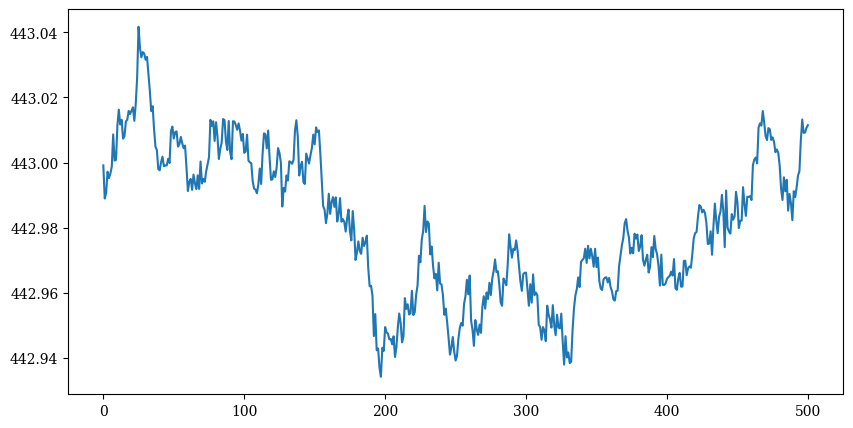

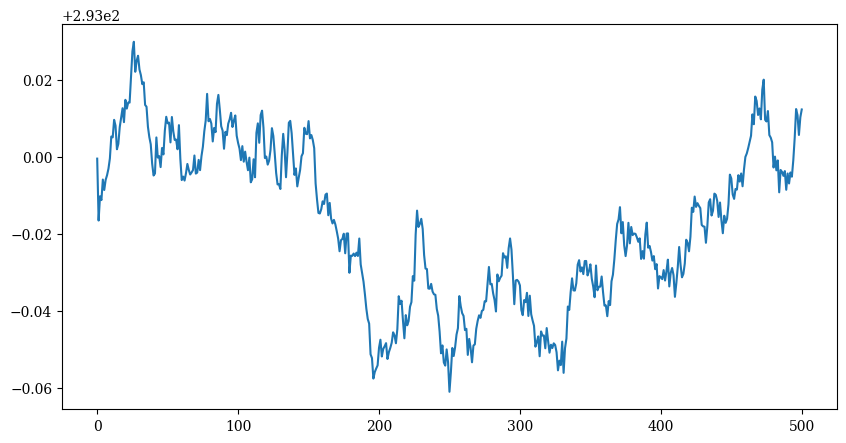

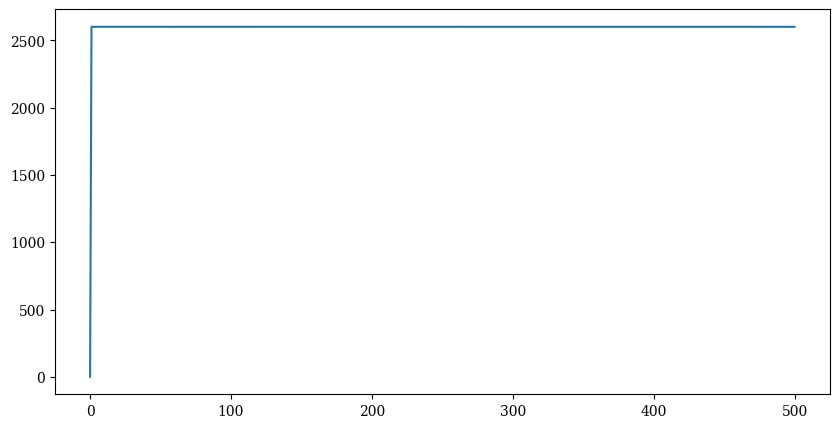

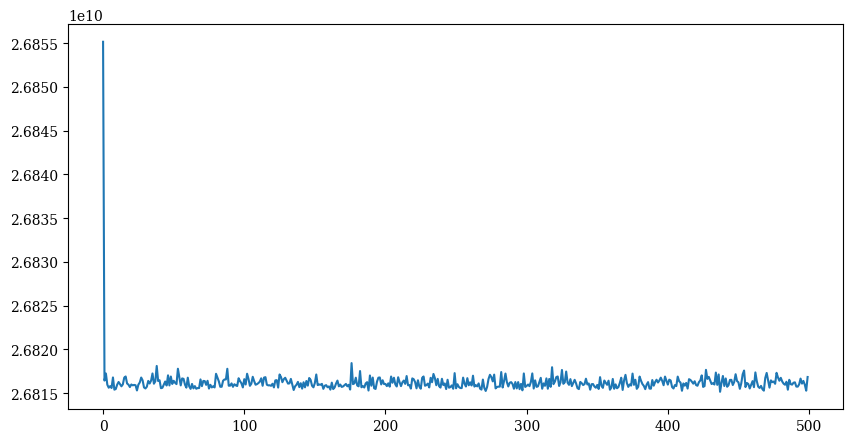

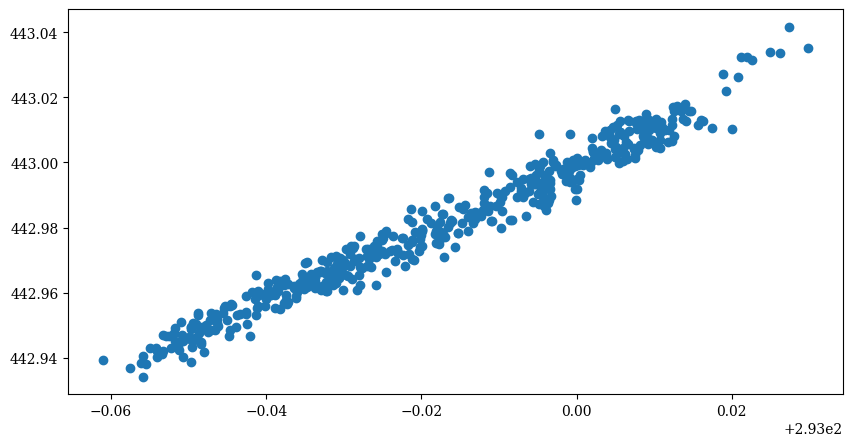

In [24]:
plt.plot(param_dict['all_p_gain'][:,-1])
plt.show()
plt.plot(param_dict['all_p_cal_src'][:, -1])
plt.show()
plt.plot(param_dict['all_p_cal_src'][:, 0])
plt.show()
plt.plot(param_dict['all_p_ant_nw'][:, 0])
plt.show()

plt.plot(param_dict['all_chi_squared_stats'])
plt.show()

plt.scatter(param_dict['all_p_cal_src'][:, 0], param_dict['all_p_cal_src'][:, 1])
plt.show()

In [25]:
param_dict = sample_loop(data=observation.data_waterfall.flatten(),
                         N=observation.Nw.flatten(),
                         U_gain=U_gain,
                         X_ant_nw=X_ant_noisewave,
                         X_cal_src=X_calibrator,
                         init_gain_amps=param_dict['all_p_gain'][-1],
                         init_cal_src_amps=param_dict['all_p_cal_src'][-1],
                         init_ant_nw_amps=param_dict['all_p_ant_nw'][-1],
                         cal_src_priors=cal_source_priors,
                         inv_cal_src_prior_cov=cal_source_prior_inv_cov,
                         n_iter=30000,
                         fix_cal_source=False,
                         Y_cal_src=Y_calibrator,
                         verbose=False,
                         chi_square_stats=True)

chi_sq:  26815948540.76895
Gibbs Sample - 0 / 30000
chi_sq:  26816536732.366848
Gibbs Sample - 50 / 30000
chi_sq:  26816687678.88282
Gibbs Sample - 100 / 30000
chi_sq:  26816205996.75446
Gibbs Sample - 150 / 30000
chi_sq:  26816010234.31503
Gibbs Sample - 200 / 30000
chi_sq:  26815509001.854485
Gibbs Sample - 250 / 30000
chi_sq:  26815792616.89619
Gibbs Sample - 300 / 30000
chi_sq:  26815925515.46866
Gibbs Sample - 350 / 30000
chi_sq:  26815944501.57012
Gibbs Sample - 400 / 30000
chi_sq:  26816259951.29734
Gibbs Sample - 450 / 30000
chi_sq:  26816407102.149544
Gibbs Sample - 500 / 30000
chi_sq:  26816722314.49579
Gibbs Sample - 550 / 30000
chi_sq:  26816539258.929306
Gibbs Sample - 600 / 30000
chi_sq:  26816806482.14715
Gibbs Sample - 650 / 30000
chi_sq:  26817029345.01499
Gibbs Sample - 700 / 30000
chi_sq:  26816677221.751736
Gibbs Sample - 750 / 30000
chi_sq:  26816578717.455666
Gibbs Sample - 800 / 30000
chi_sq:  26816637162.327156
Gibbs Sample - 850 / 30000
chi_sq:  26815777657.843

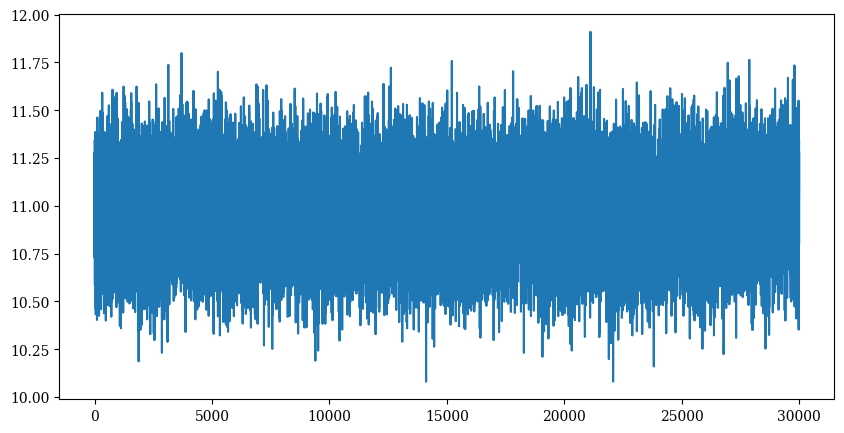

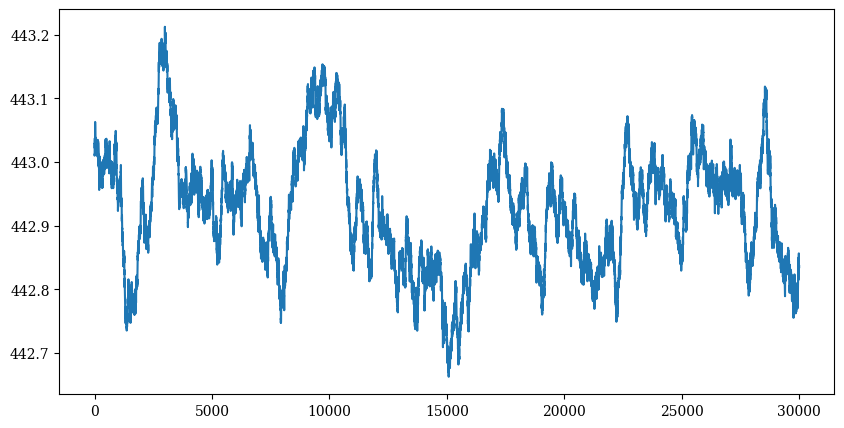

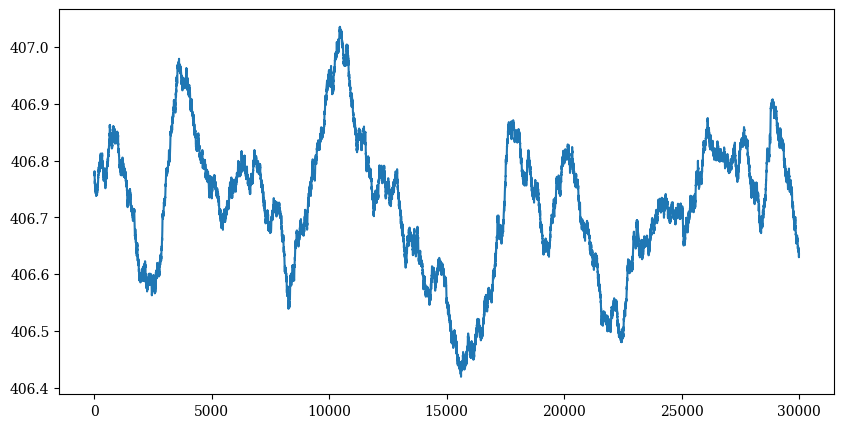

442.9248786691581


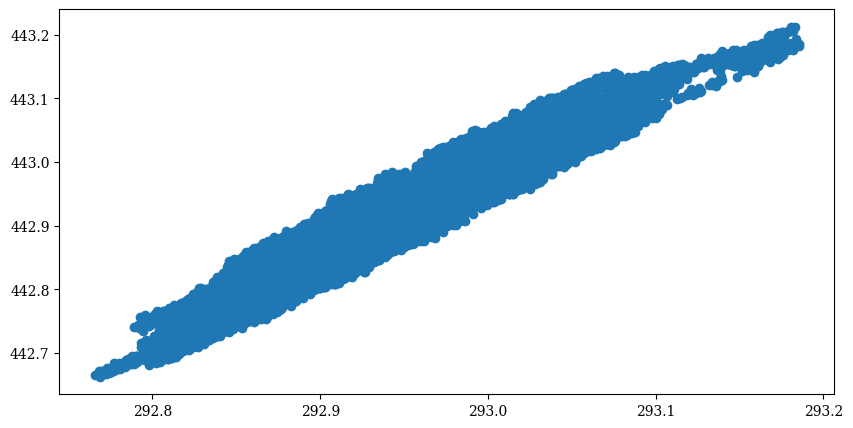

In [26]:
plt.plot(param_dict['all_p_gain'][:,-1])
plt.show()
plt.plot(param_dict['all_p_cal_src'][:, -1])
plt.show()
plt.plot(param_dict['all_p_ant_nw'][:, -1])
plt.show()

print(np.mean(param_dict['all_p_cal_src'][:, -1]))

plt.scatter(param_dict['all_p_cal_src'][:, 0], param_dict['all_p_cal_src'][:, 1])
plt.show()



[303.24148251  50.48436099  57.85203327 406.72349145]


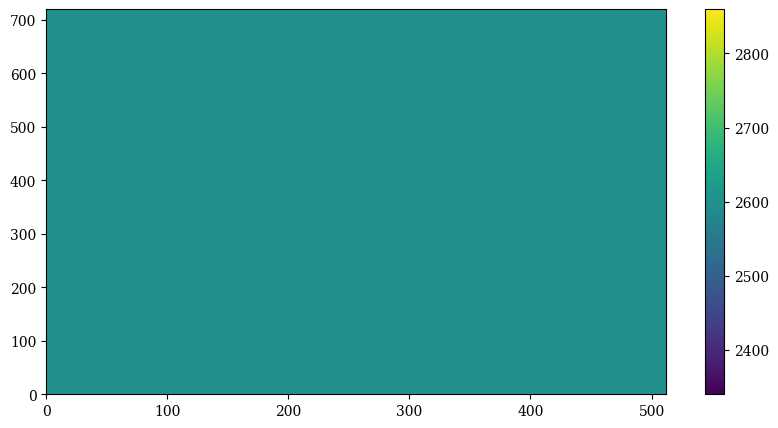

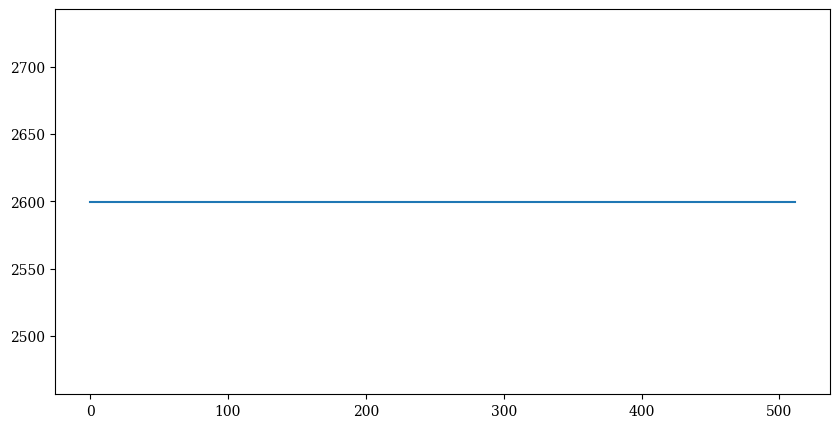

In [27]:
# Recovered Antenna

median_p_ant_nw = np.mean(param_dict['all_p_ant_nw'], axis=0)
median_p_ant = median_p_ant_nw[:len(X_antenna[0])]
median_p_nw = median_p_ant_nw[len(X_antenna[0]):]
print(median_p_nw)


reconstructed_antenna = antenna_basis.basis_matrix @ median_p_ant
reconstructed_antenna = np.reshape(reconstructed_antenna, shape=observation.data_waterfall.shape)

plt.pcolormesh(reconstructed_antenna)
plt.colorbar()
plt.show()

plt.plot(reconstructed_antenna.mean(axis=0))
plt.show()

[-3.00199494e+02  4.68925260e+02 -2.02468279e+02  5.19715763e+01
 -2.28129377e-01  0.00000000e+00 -2.60902435e+02  1.32779067e+02
 -6.75426517e+01  1.09622656e+01]


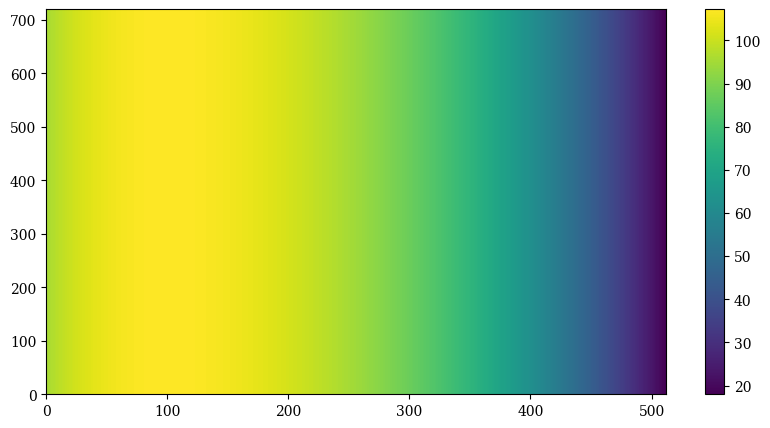

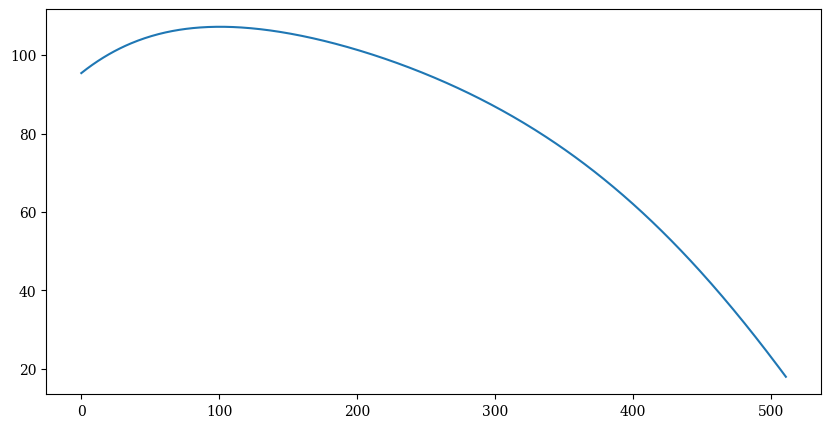

In [28]:
median_gains = np.median(param_dict['all_p_gain'], axis=0)

print(median_gains)

reconstructed_gains = gains_basis.basis_matrix @ median_gains

reconstructed_gains = np.reshape(reconstructed_gains, shape=observation.data_waterfall.shape)

plt.pcolormesh(reconstructed_gains)
plt.colorbar()
plt.show()

plt.plot(np.mean(reconstructed_gains, axis=0))
plt.show()

In [29]:
import h5py
sim_filepath = 'simulated_data/sim_data.hdf5_sim'
with h5py.File(sim_filepath) as f:
    t_unc_sim = f['t_unc'][()]
    t_sin_sim = f['t_sin'][()]
    t_cos_sim = f['t_cos'][()]
    t_rx_sim = f['t_0'][()]
    gain_sim = f['gains'][()]

## Gain Recovery

[-3.00199494e+02  4.68925260e+02 -2.02468279e+02  5.19715763e+01
 -2.28129377e-01  0.00000000e+00 -2.60902435e+02  1.32779067e+02
 -6.75426517e+01  1.09622656e+01]


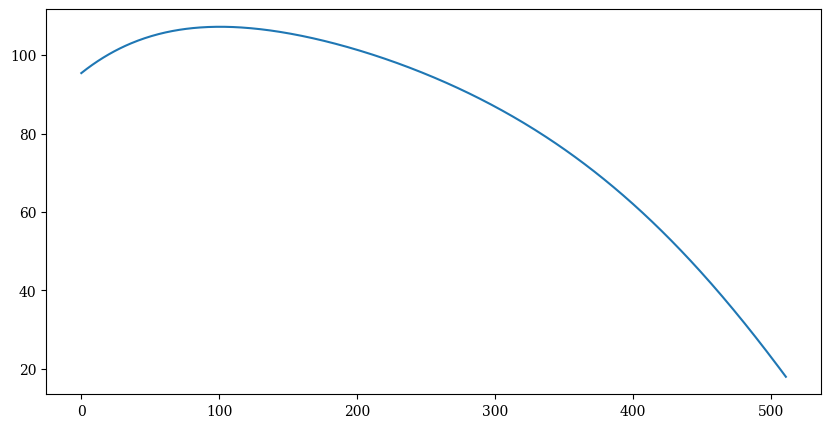

In [30]:
median_gains = np.median(param_dict['all_p_gain'], axis=0)
mean_gains = np.mean(param_dict['all_p_gain'], axis=0)
print(median_gains)

reconstructed_gains = gains_basis.basis_matrix @ median_gains

reconstructed_gains = np.reshape(reconstructed_gains, shape=observation.data_waterfall.shape)

plt.plot(np.mean(reconstructed_gains, axis=0))
plt.show()

In [31]:
def compare_sim_and_recontructed(simulated_surface,
                                 basis_obj:BasisConstructor,
                                 amplitudes,
                                 times,
                                 freqs,
                                 cmap_rec='viridis',
                                 cmap_res='RdBu',
                                 perc_diff=False,
                                 surface_label='',
                                 residvminvmax=None,
                                 figsize=(10,8)):
    fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, sharex=True, layout='constrained',
                                        figsize=figsize)

    recovered_surface = basis_obj.basis_matrix @ amplitudes
    recovered_surface = np.reshape(recovered_surface, shape=simulated_surface.shape)

    vmin = np.min(np.array([simulated_surface, recovered_surface]))
    vmax = np.max(np.array([simulated_surface, recovered_surface]))
    
    im1 = ax1.pcolormesh(freqs, times, simulated_surface, cmap=cmap_rec, vmin=vmin, vmax=vmax)
    ax1.set_title('True Simulated')

    im2 = ax2.pcolormesh(freqs, times, recovered_surface, cmap=cmap_rec, vmin=vmin, vmax=vmax)
    ax2.set_title('Recovered')

    if perc_diff:
        res = 200 * (recovered_surface - simulated_surface) / (recovered_surface+simulated_surface)
    else:
        res = recovered_surface - simulated_surface
    

    if residvminvmax is not None:
        im3 = ax3.pcolormesh(freqs, times, res, cmap=cmap_res,
                                 vmin=-residvminvmax,
                                 vmax=residvminvmax)
    else:
        im3 = ax3.pcolormesh(freqs, times, res, cmap=cmap_res)

    fig.colorbar(im1, ax=[ax1, ax2], label=surface_label)

    if perc_diff:
        res_label='% Difference'
    else:
        res_label='Residual [K]'
    fig.colorbar(im3, ax=ax3, label=res_label)

    fig.supxlabel('Freqs [Hz]')
    fig.supylabel('Time [s]')
    plt.show()
    

## Noise Wave Param Recovery

In [32]:
param_dict['all_p_ant_nw'][ant_noise_wave_slice_dict['noise_wave']]

mean_ant_nw = param_dict['all_p_ant_nw'].mean(axis=0)

median_ant_nw = np.mean(param_dict['all_p_ant_nw'], axis=0)

# print(ant_noise_wave_slice_dict['noise_wave'])

mean_nw = median_ant_nw[ant_noise_wave_slice_dict['noise_wave']]
print(nw_slice_dict)

mean_unc = mean_nw[nw_slice_dict['unc']]
mean_cos = mean_nw[nw_slice_dict['cos']]
mean_sin = mean_nw[nw_slice_dict['sin']]
mean_rx = mean_nw[nw_slice_dict['rx']]

print(mean_unc, mean_cos, mean_sin, mean_rx)

{'unc': slice(0, 1, None), 'cos': slice(1, 2, None), 'sin': slice(2, 3, None), 'rx': slice(3, 4, None)}
[303.24148251] [50.48436099] [57.85203327] [406.72349145]


In [33]:
figsize=(5,10)

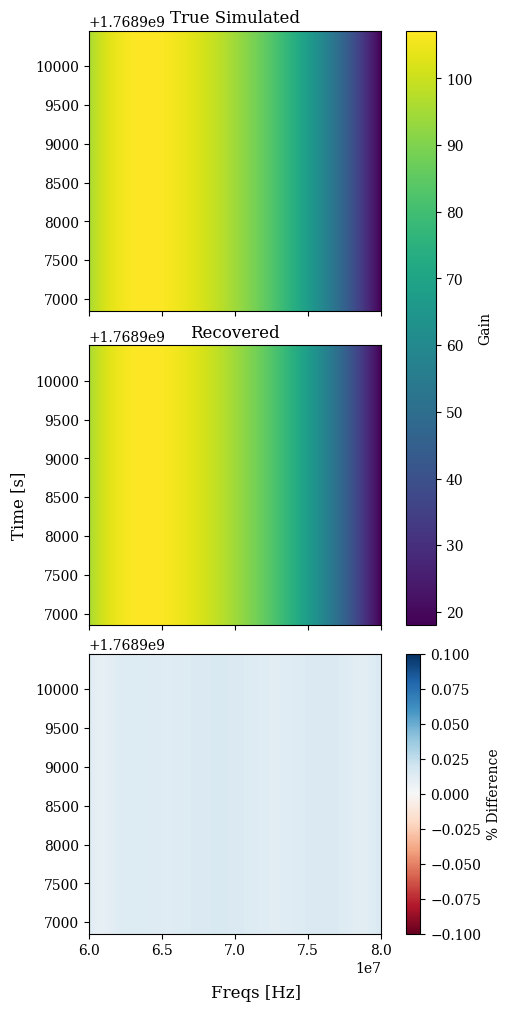

In [34]:
compare_sim_and_recontructed(gain_sim,
                             gains_basis,
                             mean_gains,
                             observation.times,
                             observation.freqs,
                             surface_label='Gain',
                             perc_diff=True,
                             residvminvmax=0.1,
                             figsize=figsize)

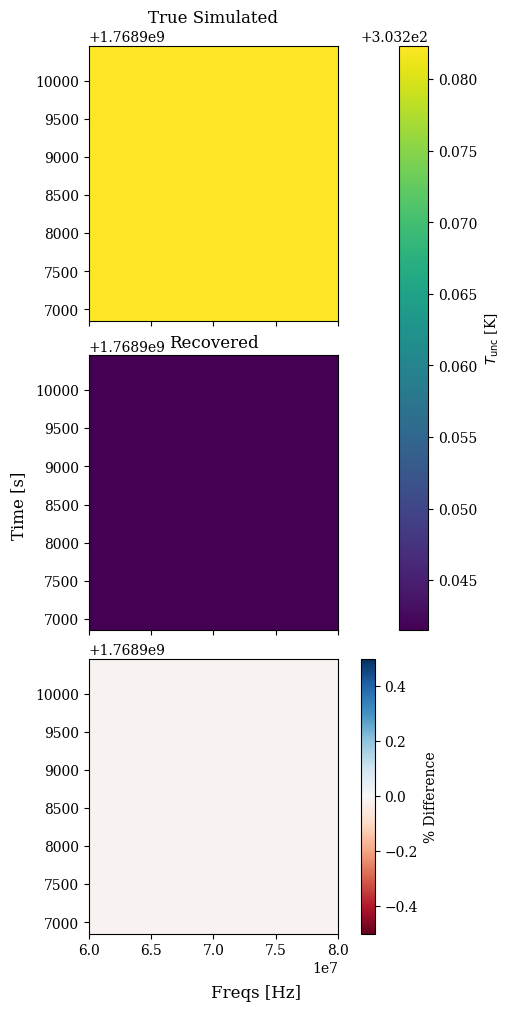

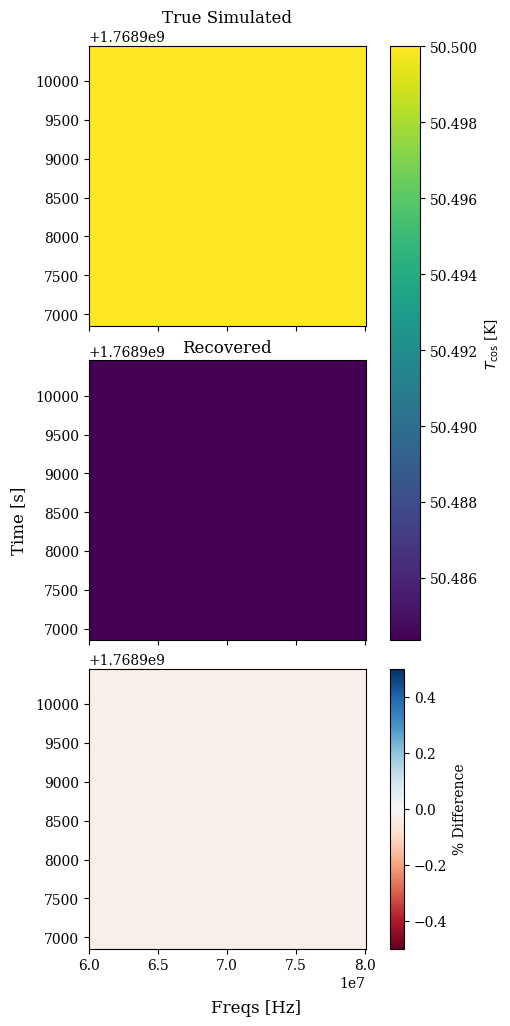

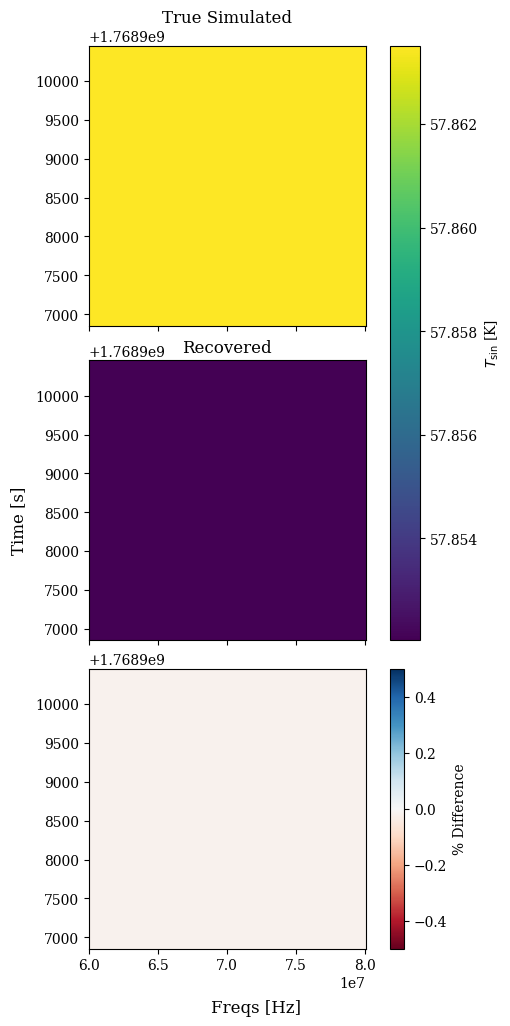

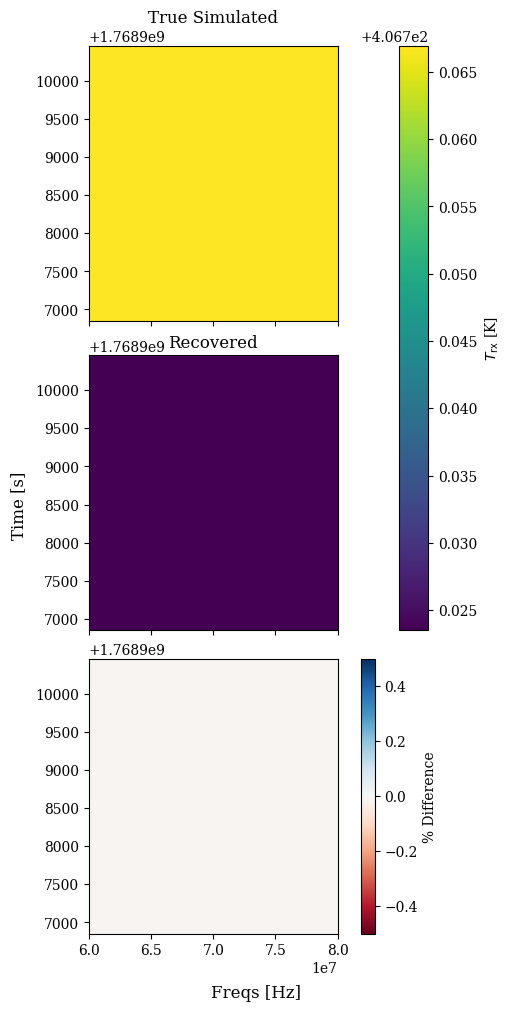

In [35]:
figsize=(5,10)

compare_sim_and_recontructed(t_unc_sim,
                             unc_basis,
                             mean_unc,
                             observation.times,
                             observation.freqs,
                             perc_diff=True,
                             residvminvmax=0.5,
                             surface_label=r'$T_{\rm unc}$ [K]',
                             figsize=figsize)
compare_sim_and_recontructed(t_cos_sim,
                             cos_basis,
                             mean_cos,
                             observation.times,
                             observation.freqs,
                             perc_diff=True,
                             residvminvmax=0.5,
                             surface_label=r'$T_{\rm cos}$ [K]',
                             figsize=figsize)
compare_sim_and_recontructed(t_sin_sim,
                             sin_basis,
                             mean_sin,
                             observation.times,
                             observation.freqs,
                             perc_diff=True,
                             residvminvmax=0.5,
                             surface_label=r'$T_{\rm sin}$ [K]',
                             figsize=figsize)
compare_sim_and_recontructed(t_rx_sim,
                             rx_basis,
                             mean_rx,
                             observation.times,
                             observation.freqs,
                             perc_diff=True,
                             residvminvmax=0.5,
                             surface_label=r'$T_{\rm rx}$ [K]',
                             figsize=figsize)

In [36]:
def plot_corner(
    chains: np.ndarray,
    labels: list[str] | None = None,
    truths: list[float] | None = None,
    title: str | None = None,
    **corner_kwargs,
):
    """
    Plot posterior densities and parameter correlations using corner.py.

    Parameters
    ----------
    chains : np.ndarray
        Array of parameter chains with shape:
        (n_samples, n_parameters)

    labels : list[str], optional
        Names of the parameters.

    truths : list[float], optional
        True/reference values for each parameter.

    title : str, optional
        Optional figure title.

    **corner_kwargs
        Additional keyword arguments passed to corner.corner().

    Returns
    -------
    fig : matplotlib.figure.Figure
        The generated corner plot figure.
    """

    import corner
    chains = np.asarray(chains)

    if chains.ndim != 2:
        raise ValueError(
            f"chains must be 2D with shape (n_samples, n_parameters), "
            f"got shape {chains.shape}"
        )

    n_parameters = chains.shape[1]

    if labels is not None and len(labels) != n_parameters:
        raise ValueError(
            f"Expected {n_parameters} labels, got {len(labels)}"
        )

    if truths is not None and len(truths) != n_parameters:
        raise ValueError(
            f"Expected {n_parameters} truths, got {len(truths)}"
        )

    one_sigma_1d = 0.683
    q_lower = 1 / 2 - one_sigma_1d / 2
    q_upper = 1 / 2 + one_sigma_1d / 2

    one_sigma_2d = 0.393

    three_sigma_1d = 0.997
    q_lower_3 = 1 / 2 - three_sigma_1d / 2
    q_upper_3 = 1 / 2 + three_sigma_1d / 2

    fig = corner.corner(
        chains,
        labels=labels,
        truths=truths,
        quantiles=(q_lower, q_upper),
        #levels=one_sigma_2d
        **corner_kwargs,
    )

    if title is not None:
        fig.suptitle(title)

    return fig


In [37]:
noise_wave_chains = param_dict['all_p_ant_nw'][:,ant_noise_wave_slice_dict['noise_wave']]


noise_diode_chain = param_dict['all_p_ant_nw'][:,ant_noise_wave_slice_dict['antenna']]

print(noise_diode_chain[:,-1])


[2600.25887332 2600.15225497 2600.11663915 ... 2599.19853353 2599.13654472
 2599.24286346]


[293.01225699 293.00782681 293.01412392 ... 292.89166038 292.88802234
 292.88973491] [443.01150764 443.00989615 443.01155786 ... 442.83795375 442.8364297
 442.83518788]


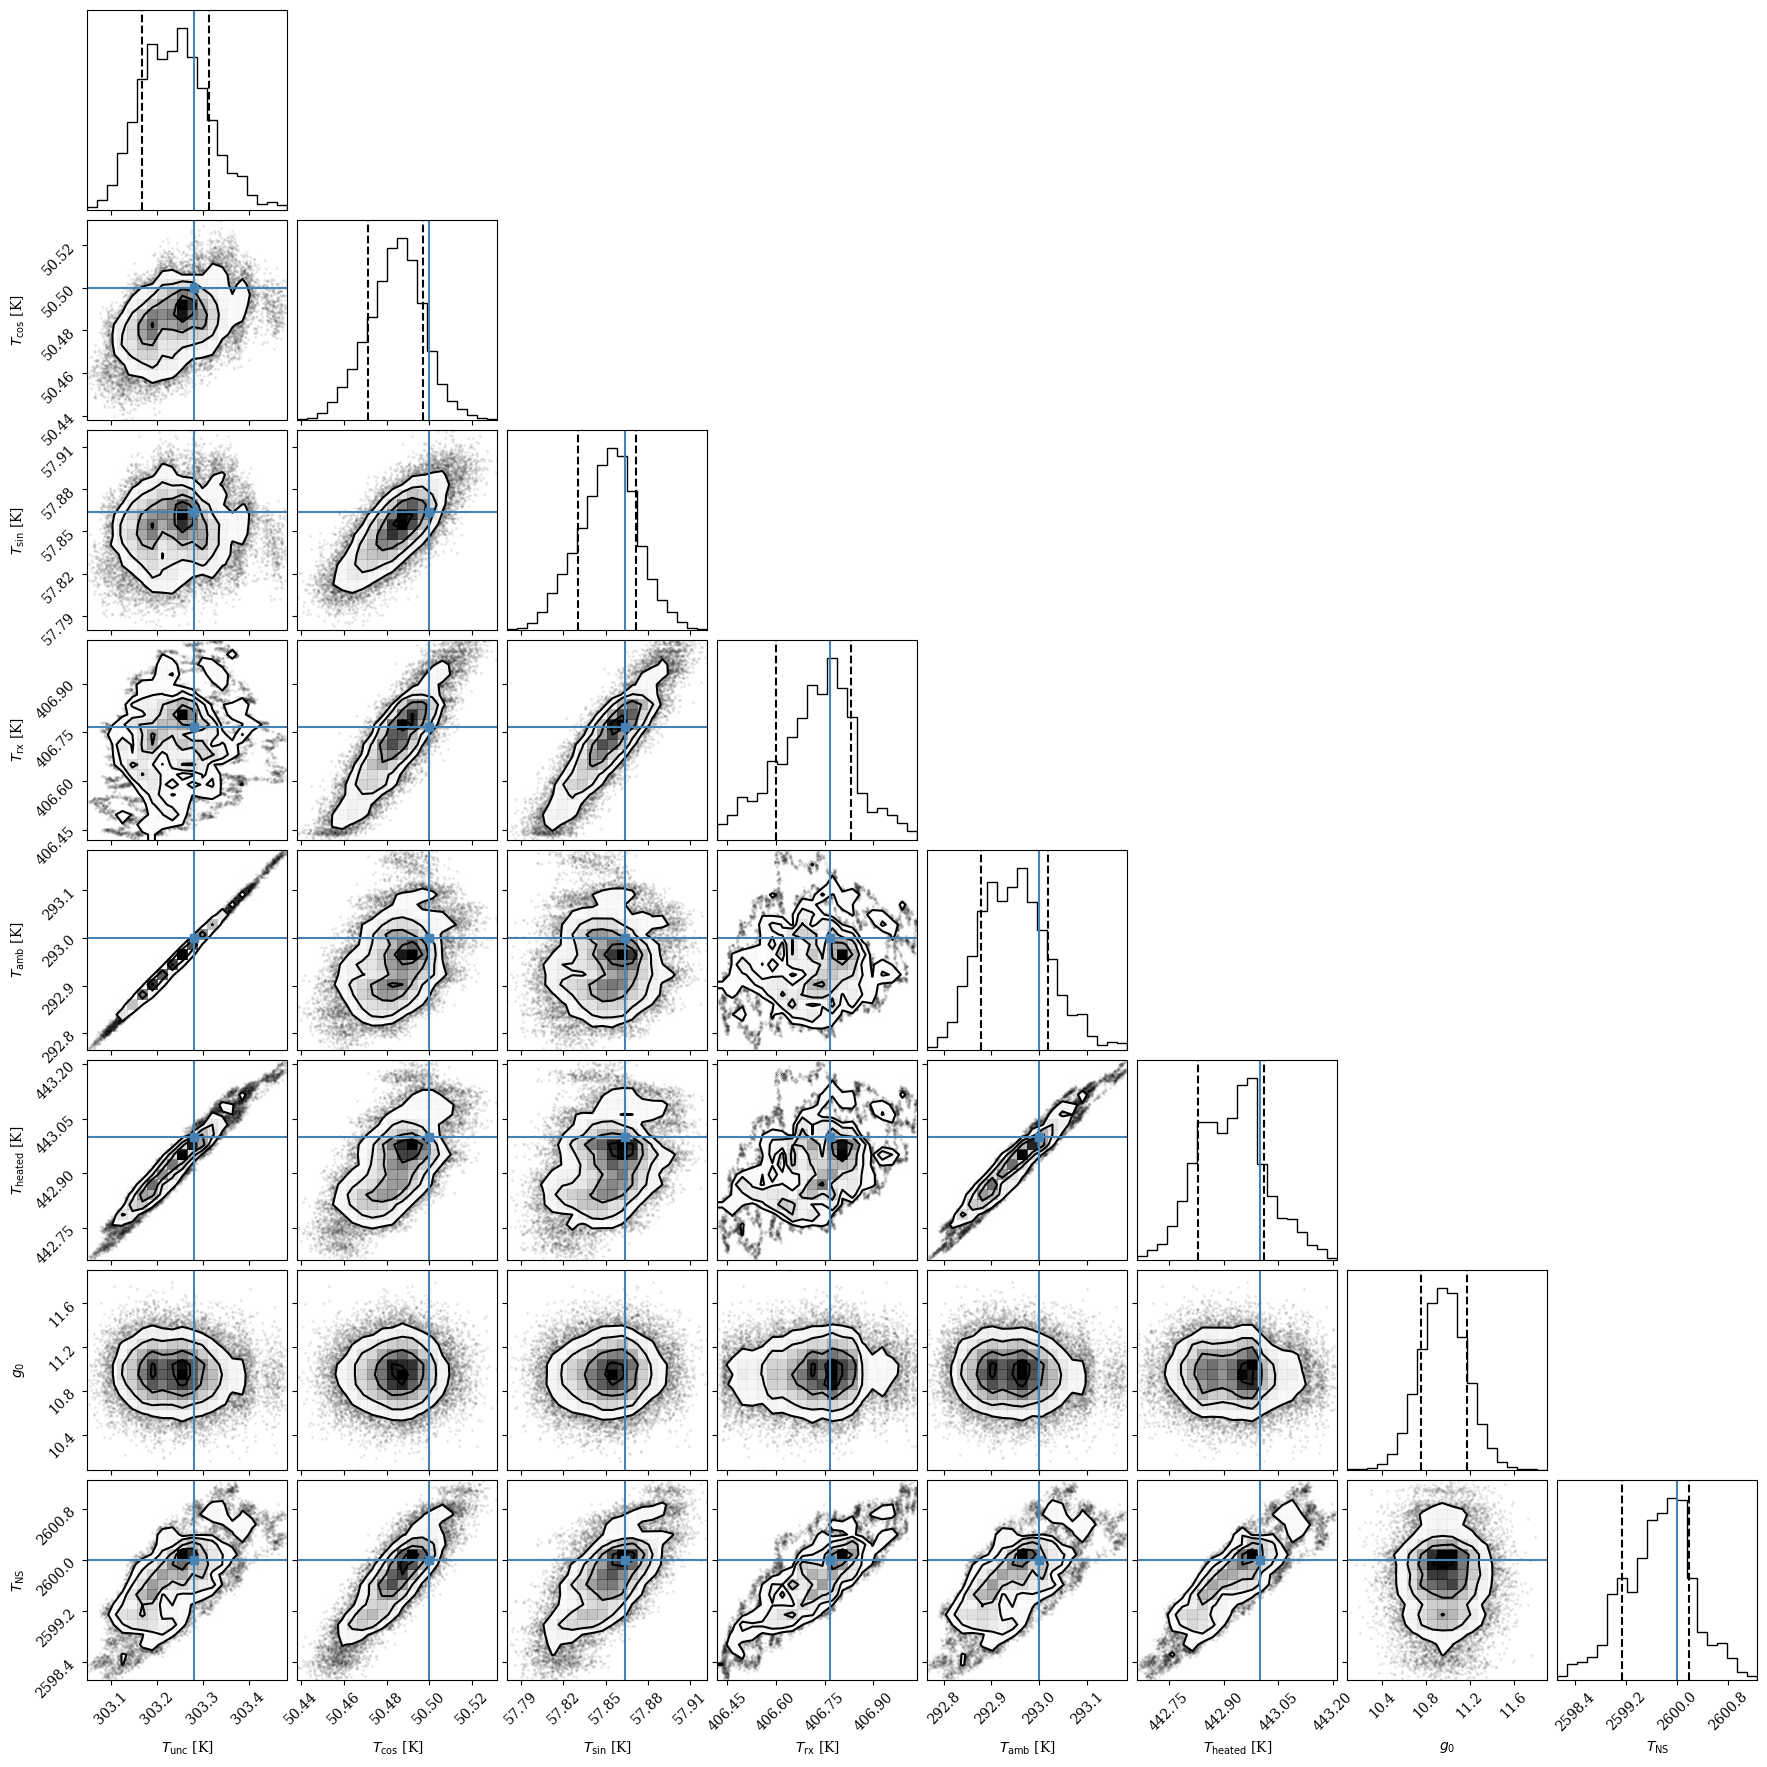

In [46]:

t_unc_chains = noise_wave_chains[:,nw_slice_dict['unc']]
t_sin_chains = noise_wave_chains[:,nw_slice_dict['sin']]
t_cos_chains = noise_wave_chains[:,nw_slice_dict['cos']]
t_rx_chains = noise_wave_chains[:,nw_slice_dict['rx']]

t_amb_chains = param_dict['all_p_cal_src'][:,0]
t_heated_chains = param_dict['all_p_cal_src'][:,1]
print(t_amb_chains, t_heated_chains)

param_dict['all_p_gain']

gain_chain = param_dict['all_p_gain'][:,-1]



chains = np.column_stack([
    t_unc_chains[:,-1],
    t_cos_chains[:,-1],
    t_sin_chains[:,-1],
    t_rx_chains[:,-1],
    t_amb_chains,
    t_heated_chains,
    gain_chain,
    noise_diode_chain[:,-1]
])

fig = plot_corner(
    chains,
    labels=[
        r'$T_{\rm unc}$ [K]',
        r'$T_{\rm cos}$ [K]',
        r'$T_{\rm sin}$ [K]',
        r'$T_{\rm rx}$ [K]',
        r'$T_{\rm amb}$ [K]',
        r'$T_{\rm heated}$ [K]',
        r'$g_0$',
        r'$T_{\rm NS}$'
    ],
    truths=[
        np.mean(t_unc_sim),
        np.mean(t_cos_sim),
        np.mean(t_sin_sim),
        np.mean(t_rx_sim),
        293,
        293+150,
        np.mean(gain_sim),
        2600
    ]
)

plt.show()

# Construct $z$-score waterfall

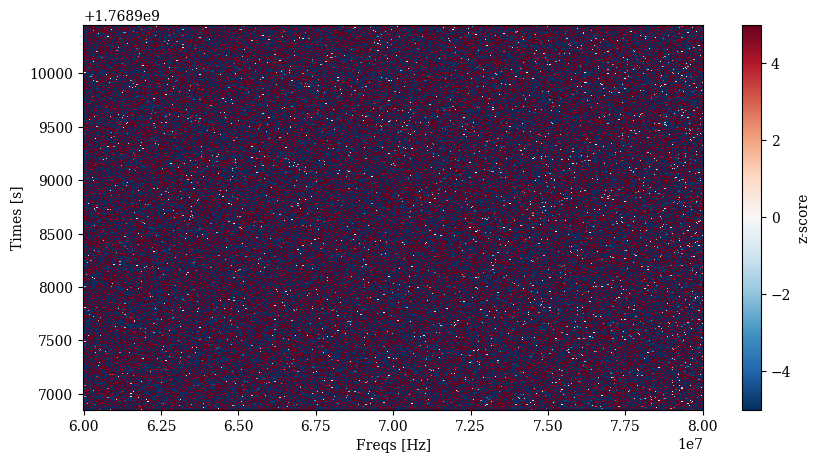

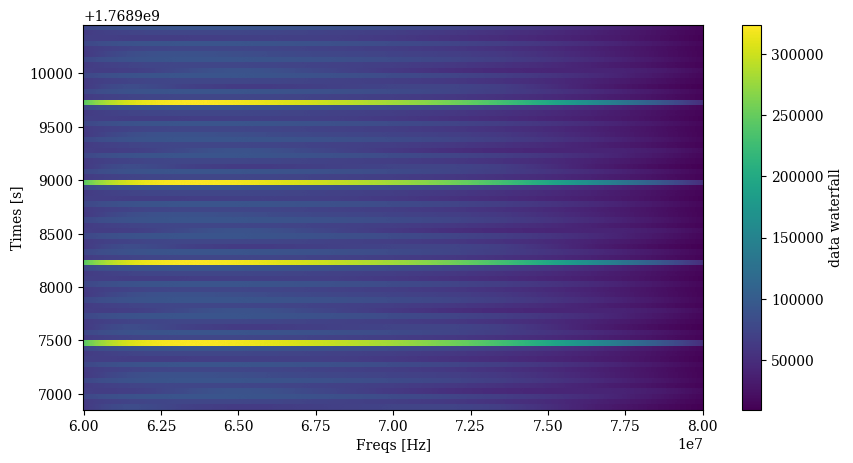

165.55732982026996


In [39]:
mad_model = (gains_basis.basis_matrix @ param_dict['all_p_gain'].mean(axis=0)) *\
    ((X_ant_noisewave @ param_dict['all_p_ant_nw'].mean(axis=0) + X_calibrator @ param_dict['all_p_cal_src'].mean(axis=0)))

cov = observation.Nw.flatten() * mad_model
sigma = np.sqrt(cov)
del cov

z = (observation.data_waterfall.flatten() - mad_model) / sigma
z = np.reshape(z, observation.data_waterfall.shape)

plt.pcolormesh(observation.freqs,
               observation.times,
               z,
               vmin=-5,
               vmax=5,
               cmap='RdBu_r')
plt.colorbar(label='z-score')
plt.ylabel('Times [s]')
plt.xlabel('Freqs [Hz]')
plt.show()


plt.pcolormesh(observation.freqs,
               observation.times,
               observation.data_waterfall,)
plt.colorbar(label='data waterfall')
plt.ylabel('Times [s]')
plt.xlabel('Freqs [Hz]')
plt.show()

print(np.median(np.abs(z)))

### Plot all Receiver calibration terms


In [40]:
def compare_sim_and_recontructed_all(true_gain_surface,
                                     gain_amplitudes,
                                     gain_basis:BasisConstructor,
                                     true_t_unc_surface,
                                     t_unc_amplitudes,
                                     t_unc_basis,
                                     true_t_cos_surface,
                                     t_cos_amplitudes,
                                     t_cos_basis:BasisConstructor,
                                     true_t_sin_surface,
                                     t_sin_amplitudes,
                                     t_sin_basis:BasisConstructor,
                                     true_t_rx_surface,
                                     t_rx_amplitudes,
                                     t_rx_basis:BasisConstructor,
                                     waterfall_shape,
                                     times,
                                     freqs,
                                     cmap_rec='viridis',
                                     cmap_res='RdBu',
                                     perc_diff=False,
                                     residvminvmax=None,
                                     figsize=(10,8),
                                     gain_cmap='viridis',
                                     t_unc_cmap='plasma',
                                     t_cos_cmap='inferno',
                                     t_sin_cmap='cividis',
                                     t_rx_cmap='magma',
                                     savepath: str|None=None):

    fig, axes = plt.subplots(
        nrows=3,
        ncols=5,
        sharex=True,
        layout='constrained',
        figsize=figsize,
        sharey=True
        )

    freqs /= 1e6
    
    # Gains
    rec_gain_surface = gains_basis.basis_matrix @ gain_amplitudes
    rec_gain_surface = np.reshape(
        rec_gain_surface,
        waterfall_shape
    )

    gain = axes[0,0].pcolormesh(
        freqs,
        times,
        true_gain_surface,
        cmap=gain_cmap
    )
    gain = axes[1,0].pcolormesh(
            freqs,
            times,
            rec_gain_surface,
            cmap=gain_cmap
        )

    perc_diff = 200*(true_gain_surface - rec_gain_surface) / \
        (true_gain_surface + rec_gain_surface)

    res = axes[2,0].pcolormesh(
            freqs,
            times,
            perc_diff,
            cmap=cmap_res,
            vmin=-residvminvmax,
            vmax=residvminvmax
        )

    del rec_gain_surface, true_gain_surface,perc_diff


    # Unc
    rec_unc_surface = unc_basis.basis_matrix @ t_unc_amplitudes
    rec_unc_surface = np.reshape(
        rec_unc_surface,
        waterfall_shape
    )

    unc = axes[0,1].pcolormesh(
        freqs,
        times,
        true_t_unc_surface,
        cmap=t_unc_cmap
    )
    unc = axes[1,1].pcolormesh(
            freqs,
            times,
            rec_unc_surface,
            cmap=t_unc_cmap
        )

    perc_diff = 200*(true_t_unc_surface - rec_unc_surface) / \
        (true_t_unc_surface + rec_unc_surface)

    res = axes[2,1].pcolormesh(
            freqs,
            times,
            perc_diff,
            cmap=cmap_res,
            vmin=-residvminvmax,
            vmax=residvminvmax
        )

    del rec_unc_surface, true_t_unc_surface,perc_diff


    # Cos
    rec_cos_surface = cos_basis.basis_matrix @ t_cos_amplitudes
    rec_cos_surface = np.reshape(
        rec_cos_surface,
        waterfall_shape
    )

    cos = axes[0,2].pcolormesh(
        freqs,
        times,
        true_t_cos_surface,
        cmap=t_cos_cmap
    )
    cos = axes[1,2].pcolormesh(
            freqs,
            times,
            rec_cos_surface,
            cmap=t_cos_cmap
        )

    perc_diff = 200*(true_t_cos_surface - rec_cos_surface) / \
        (true_t_cos_surface + rec_cos_surface)

    res = axes[2,2].pcolormesh(
            freqs,
            times,
            perc_diff,
            cmap=cmap_res,
            vmin=-residvminvmax,
            vmax=residvminvmax
        )

    del rec_cos_surface, true_t_cos_surface,perc_diff

    # Sin
    rec_sin_surface = sin_basis.basis_matrix @ t_sin_amplitudes
    rec_sin_surface = np.reshape(
        rec_sin_surface,
        waterfall_shape
    )

    sin = axes[0,3].pcolormesh(
        freqs,
        times,
        true_t_sin_surface,
        cmap=t_sin_cmap
    )
    sin = axes[1,3].pcolormesh(
            freqs,
            times,
            rec_sin_surface,
            cmap=t_sin_cmap
        )

    perc_diff = 200*(true_t_sin_surface - rec_sin_surface) / \
        (true_t_sin_surface + rec_sin_surface)

    res = axes[2,3].pcolormesh(
            freqs,
            times,
            perc_diff,
            cmap=cmap_res,
            vmin=-residvminvmax,
            vmax=residvminvmax
        )

    del rec_sin_surface, true_t_sin_surface,perc_diff

    # Rx
    rec_rx_surface = rx_basis.basis_matrix @ t_rx_amplitudes
    rec_rx_surface = np.reshape(
        rec_rx_surface,
        waterfall_shape
    )

    rx = axes[0,4].pcolormesh(
        freqs,
        times,
        true_t_rx_surface,
        cmap=t_rx_cmap
    )
    rx = axes[1,4].pcolormesh(
            freqs,
            times,
            rec_rx_surface,
            cmap=t_rx_cmap
        )

    perc_diff = 200*(true_t_rx_surface - rec_rx_surface) / \
        (true_t_rx_surface + rec_rx_surface)

    res = axes[2,4].pcolormesh(
            freqs,
            times,
            perc_diff,
            cmap=cmap_res,
            vmin=-residvminvmax,
            vmax=residvminvmax
        )

    del rec_rx_surface, true_t_rx_surface,perc_diff

    axes[0,0].set_ylabel('True')
    axes[1,0].set_ylabel('Maximum Likelihood')

    fig.colorbar(res,
                 ax=[axes[2,i] for i in range(5)],
                 label='% Difference',
                 extend='both')

    fig.colorbar(
        unc,
        ax=[axes[i,1] for i in range(2)],
        label=r'$T_{\rm unc}$ [K]'
    )
    fig.colorbar(
            cos,
            ax=[axes[i,2] for i in range(2)],
            label=r'$T_{\rm cos}$ [K]'
        )
    fig.colorbar(
            sin,
            ax=[axes[i,3] for i in range(2)],
            label=r'$T_{\rm sin}$ [K]'
        )
    fig.colorbar(
            rx,
            ax=[axes[i,4] for i in range(2)],
            label=r'$T_{\rm rx}$ [K]'
        )
    fig.colorbar(
            gain,
            ax=[axes[i,0] for i in range(2)],
            label=r'Gain [K$^{-1}$]'
        )

    fig.supxlabel(r'Freq [MHz]')
    fig.supylabel(r'Time [s]')
    if savepath is not None:
        fig.savefig(fname=savepath)
    plt.show()
    

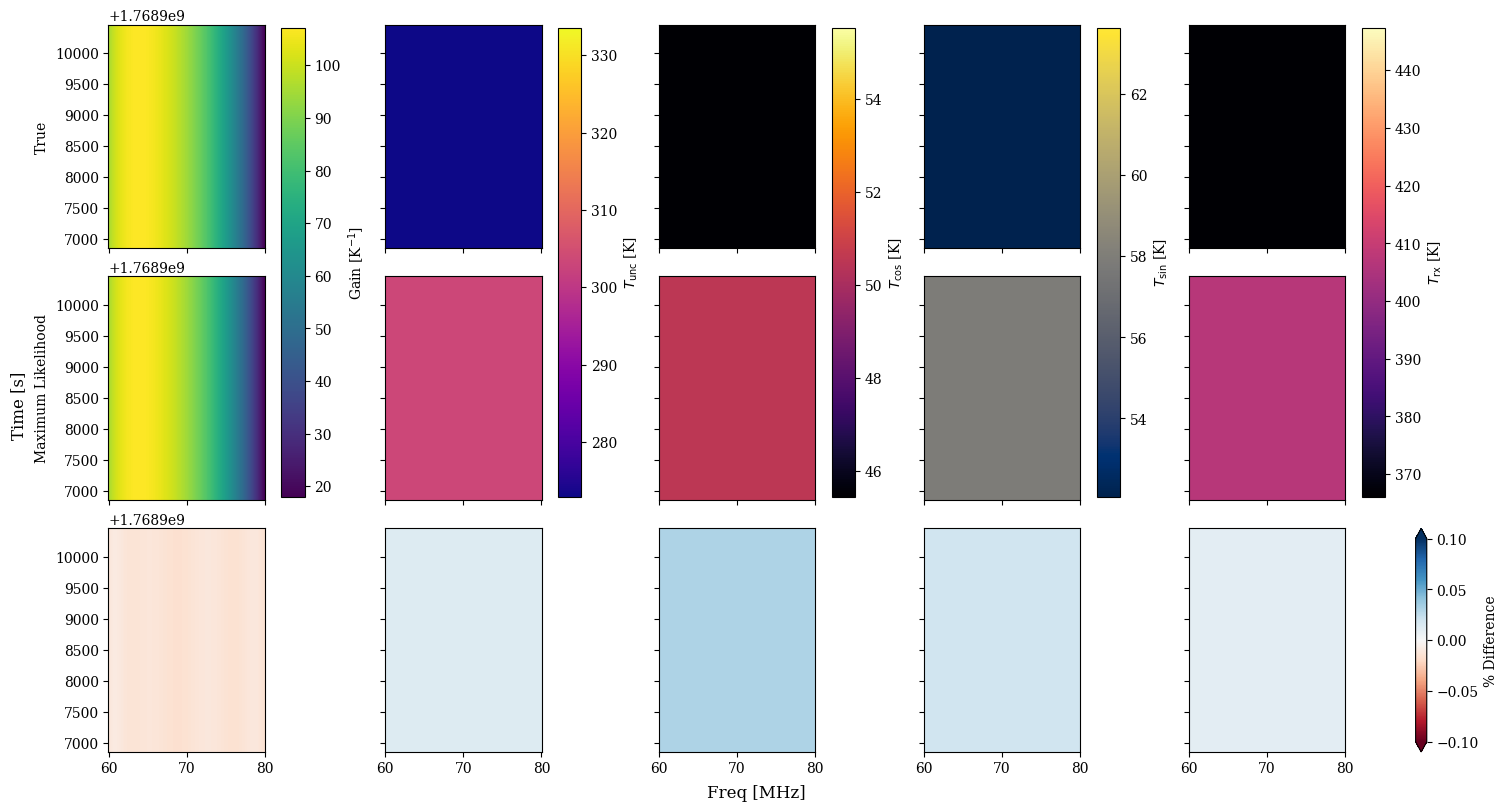

In [41]:
compare_sim_and_recontructed_all(
    true_gain_surface=gain_sim,
    gain_amplitudes=mean_gains,
    gain_basis=gains_basis,
    true_t_unc_surface=t_unc_sim,
    t_unc_amplitudes=mean_unc,
    t_unc_basis=unc_basis,
    true_t_cos_surface=t_cos_sim,
    t_cos_amplitudes=mean_cos,
    t_cos_basis=cos_basis,
    true_t_sin_surface=t_sin_sim,
    t_sin_amplitudes=mean_sin,
    t_sin_basis=sin_basis,
    true_t_rx_surface=t_rx_sim,
    t_rx_amplitudes=mean_rx,
    t_rx_basis=rx_basis,
    waterfall_shape=observation.data_waterfall.shape,
    times=observation.times,
    freqs=observation.freqs,
    residvminvmax=0.1,
    figsize=(15,8),
    # savepath='plots/calibration_map_sol.pdf'
)

# Plot 1D Distribution


In [42]:
def plot_1d_spectra(
        true_surface,
        basis:BasisConstructor,
        chains,
        freqs,
        waterfall_shape,
        ylabel,
        color='green',
):
    quantiles = [0.5-(0.97/2),
                 0.5-(0.68/2),
                 0.5,
                 0.5+(0.97/2),
                 0.5+(0.68/2)]
    # Get the quantiled from chains
    param_quantile_list = [
        np.quantile(chains,
                    q,
                    axis=0) for q in quantiles
    ]
    mean_chain = np.mean(chains, axis=0)

    true_spectra = np.mean(true_surface, axis=0)
    del true_surface
    def reproduce_spectra(amps):
        rec = basis.basis_matrix @ amps
        rec = np.reshape(rec, waterfall_shape)
        return rec.mean(axis=0)


    mean_chain_spectra = reproduce_spectra(mean_chain)
    median_chain_spectra = reproduce_spectra(np.quantile(chains,
                                                         0.5,
                                                         axis=0))

    one_sigma_bounds = [reproduce_spectra(np.quantile(chains,
                                                         0.5-(0.68/2),
                                                         axis=0)),
                        reproduce_spectra(np.quantile(chains,
                                                      0.5+(0.68/2),
                                                      axis=0)),]


    reproduced_gains = np.array(
        [reproduce_spectra(chain_i) for chain_i in chains]
        )

    mean_gain = np.mean(reproduced_gains, axis=0)
    median_gain = np.median(reproduced_gains, axis=0)

    sigma_bounds = [
        np.quantile(reproduced_gains, 0.5-(0.68/2), axis=0),
        np.quantile(reproduced_gains, 0.5+(0.68/2), axis=0)
    ]
    three_sigma_bounds = [
            np.quantile(reproduced_gains, 0.5-(0.997/2), axis=0),
            np.quantile(reproduced_gains, 0.5+(0.997/2), axis=0)
        ]

    plt.plot(freqs, true_spectra, label='Truth')
    plt.plot(freqs, mean_gain, label='Mean')
    plt.plot(freqs, median_gain, label='Median')
    plt.fill_between(freqs, sigma_bounds[0], sigma_bounds[-1],
                     color=color, alpha=0.25)
    
    plt.fill_between(freqs, three_sigma_bounds[0], three_sigma_bounds[-1],
                     color=color, alpha=0.25)
    
    plt.show()
    plt.plot(freqs, mean_gain-true_spectra, label='Mean')
    plt.plot(freqs, median_gain-true_spectra, label='Median')
    plt.fill_between(freqs, sigma_bounds[0]-true_spectra, 
                     sigma_bounds[-1]-true_spectra,
                         color=color, alpha=0.25)
    plt.fill_between(freqs, three_sigma_bounds[0]-true_spectra, 
                         three_sigma_bounds[-1]-true_spectra,
                             color=color, alpha=0.25)
    plt.legend()
    plt.show()


    

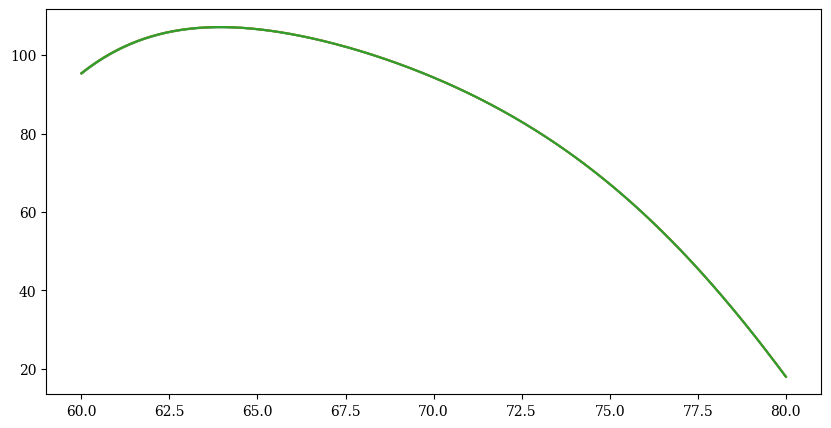

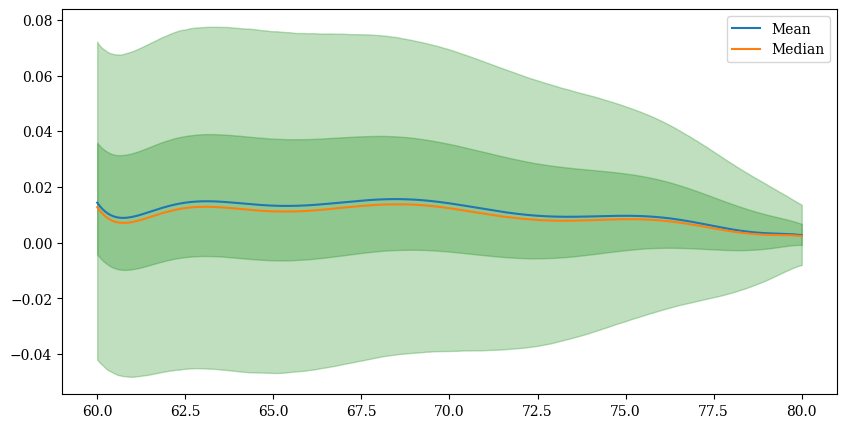

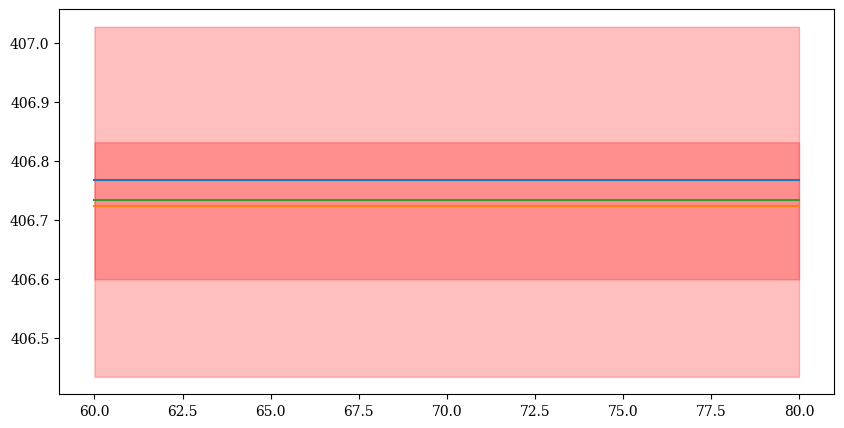

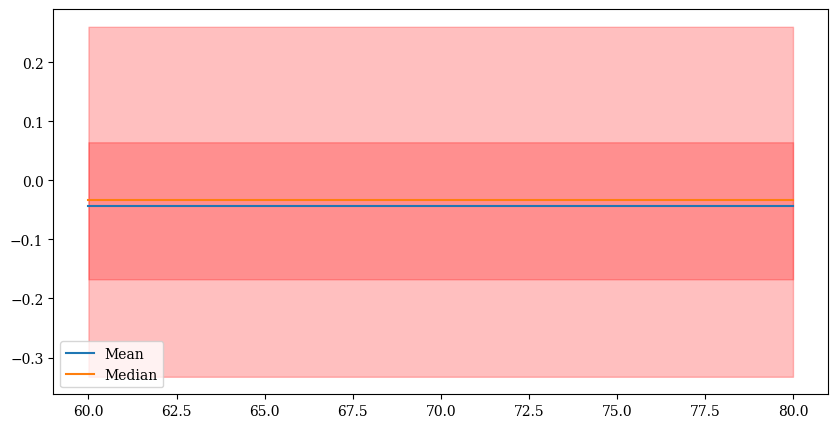

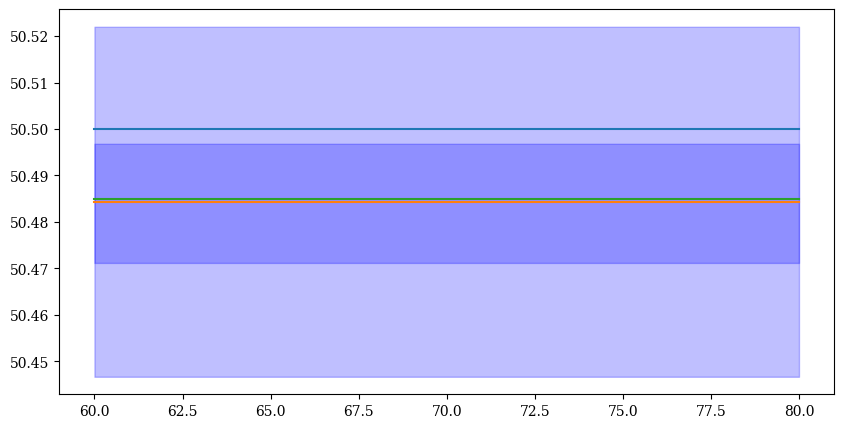

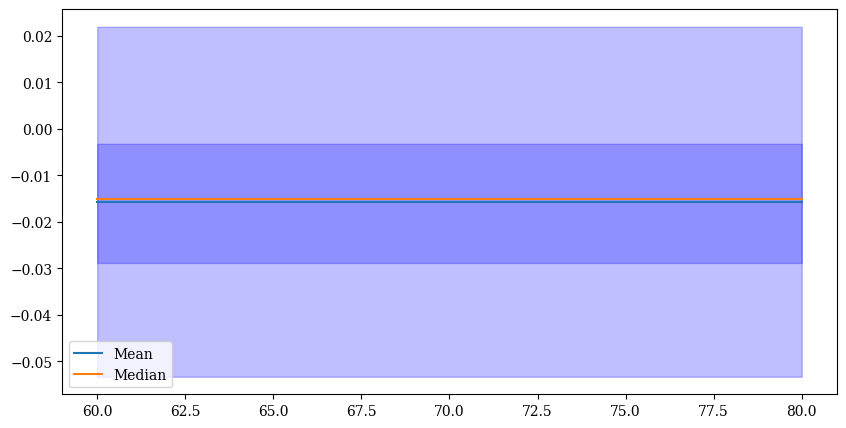

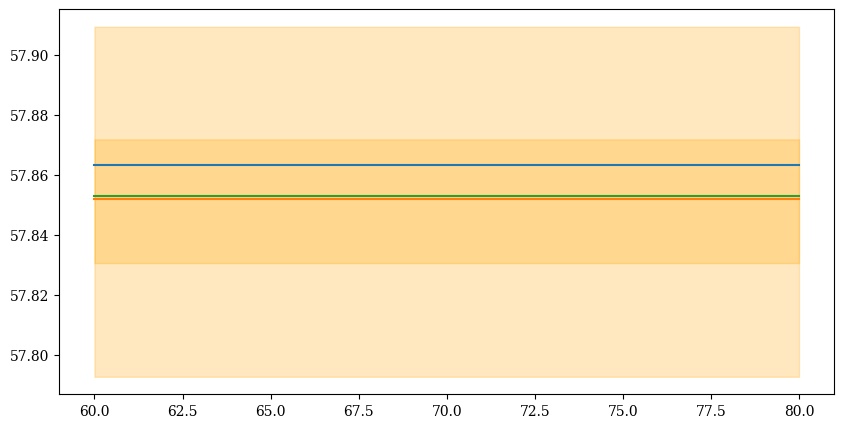

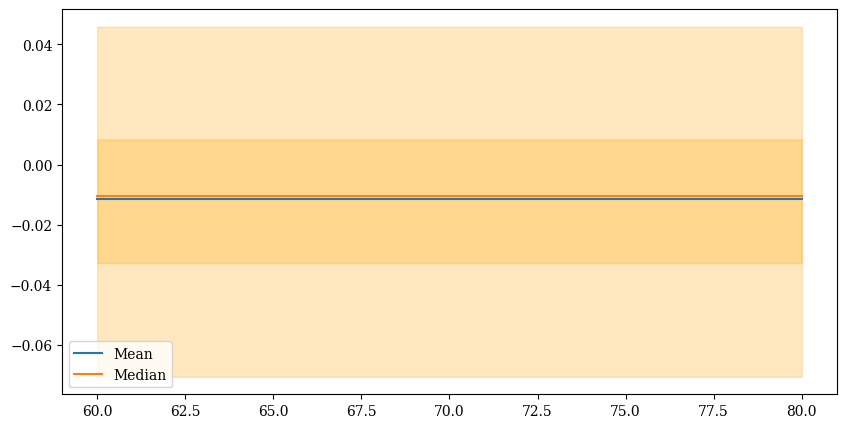

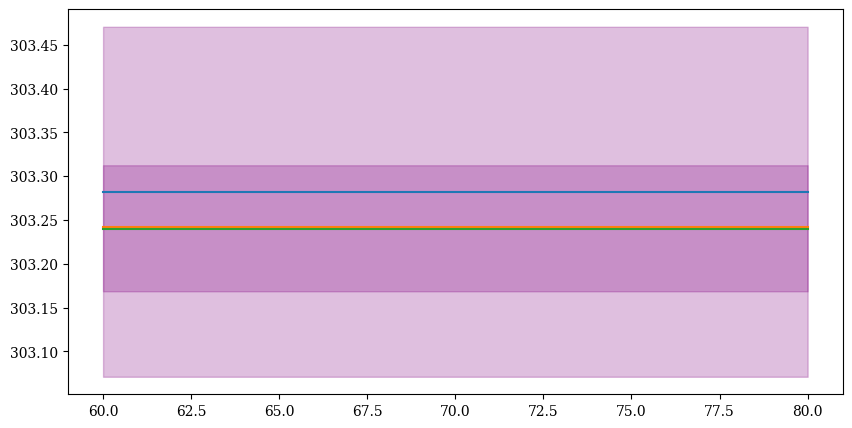

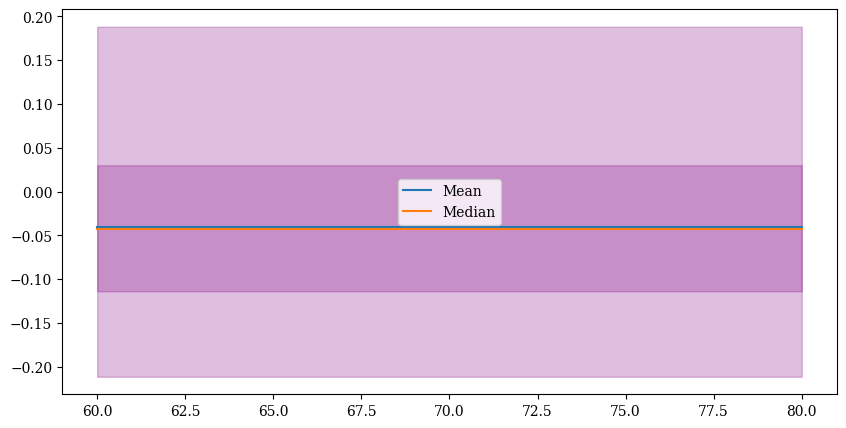

In [43]:
plot_1d_spectra(gain_sim,
                basis=gains_basis,
                chains=param_dict['all_p_gain'],
                freqs=observation.freqs,
                waterfall_shape=observation.data_waterfall.shape,
                ylabel='')
plot_1d_spectra(t_rx_sim,
                basis=rx_basis,
                chains=t_rx_chains,
                freqs=observation.freqs,
                waterfall_shape=observation.data_waterfall.shape,
                ylabel=r'$T_{\rm rx}$',
                color='red')
plot_1d_spectra(t_cos_sim,
                basis=cos_basis,
                chains=t_cos_chains,
                freqs=observation.freqs,
                waterfall_shape=observation.data_waterfall.shape,
                ylabel=r'$T_{\rm cos}$',
                color='blue')
plot_1d_spectra(t_sin_sim,
                basis=sin_basis,
                chains=t_sin_chains,
                freqs=observation.freqs,
                waterfall_shape=observation.data_waterfall.shape,
                ylabel=r'$T_{\rm sin}$',
                color='orange')
plot_1d_spectra(t_unc_sim,
                basis=unc_basis,
                chains=t_unc_chains,
                freqs=observation.freqs,
                waterfall_shape=observation.data_waterfall.shape,
                ylabel=r'$T_{\rm sin}$',
                color='purple')

In [44]:
def plot_all_1d_cal_spectra(
        gain_chain,
        unc_chain,
        cos_chain,
        sin_chain,
        rx_chain,
        gain_basis,
        unc_basis,
        cos_basis,
        sin_basis,
        rx_basis,
        true_gains,
        true_unc,
        true_cos,
        true_sin,
        true_rx,
        waterfall_shape,
        freqs,
        c_gain='green',
        c_unc='purple',
        c_cos='red',
        c_sin='blue',
        c_rx='orangered',
        c_true='black',
        saveplot=None,
        figsize=(15,10),
        alpha=0.25,
):
    fig, axes = plt.subplots(
        nrows=2,
        ncols=5,
        layout='constrained',
        figsize=figsize,
        sharex=True,
    )

    def plot_comp(full_ax,
                  resid_ax,
                  chain,
                  basis,
                  true_spec,
                  color,
                  alpha):
        def reproduce_spectra(amps):
                rec = basis.basis_matrix @ amps
                rec = np.reshape(rec, waterfall_shape)
                return rec.mean(axis=0)
        reproduced_spectra = np.array(
                [reproduce_spectra(chain_i) for chain_i in chain]
                )
        true_spec = true_spec.mean(axis=0) # convert surface to 1D

        med_spectra = np.quantile(reproduced_spectra,
                                  0.5, axis=0)
        sigma_bounds = [
                np.quantile(reproduced_spectra, 0.5-(0.68/2), axis=0),
                np.quantile(reproduced_spectra, 0.5+(0.68/2), axis=0)
            ]
        three_sigma_bounds = [
                    np.quantile(reproduced_spectra, 0.5-(0.997/2), axis=0),
                    np.quantile(reproduced_spectra, 0.5+(0.997/2), axis=0)
                ]
        

        full_ax.plot(freqs, true_spec, c=c_true, label='True')
        full_ax.plot(freqs, med_spectra, c=color, label='Max Prob.')
        full_ax.fill_between(freqs, sigma_bounds[0], sigma_bounds[-1],
                             color=color, alpha=2*alpha, label=r'$1\,\sigma$')
        full_ax.fill_between(freqs, three_sigma_bounds[0], three_sigma_bounds[-1],
                                     color=color, alpha=alpha, label=r'$3\,\sigma$')

        resid_ax.plot(freqs, med_spectra - true_spec, c=color)
        resid_ax.fill_between(freqs, sigma_bounds[0]-true_spec,
                              sigma_bounds[-1]-true_spec,
                                     color=color, alpha=2*alpha)
        resid_ax.fill_between(freqs, three_sigma_bounds[0]-true_spec,
                              three_sigma_bounds[-1]-true_spec,
                                             color=color, alpha=alpha)
        resid_ax.plot(freqs, np.zeros_like(freqs), ls='--', c='black')
        pass


    plot_comp(axes[0,0], axes[1,0], chain=gain_chain, basis=gain_basis,
              true_spec=true_gains, color=c_gain, alpha=alpha)
    plot_comp(axes[0,1], axes[1,1], chain=unc_chain, basis=unc_basis,
                  true_spec=true_unc, color=c_unc, alpha=alpha)
    plot_comp(axes[0,2], axes[1,2], chain=cos_chain, basis=cos_basis,
                  true_spec=true_cos, color=c_cos, alpha=alpha)
    plot_comp(axes[0,3], axes[1,3], chain=sin_chain, basis=sin_basis,
                  true_spec=true_sin, color=c_sin, alpha=alpha)
    plot_comp(axes[0,4], axes[1,4], chain=rx_chain, basis=rx_basis,
                  true_spec=true_rx, color=c_rx, alpha=alpha)

    fig.supxlabel(r'Frequency [MHz]')

    axes[0,0].set_ylabel(r'Gain [K$^{-1}$]')
    axes[0,1].set_ylabel(r'$T_{\rm unc}$ [K]')
    axes[0,2].set_ylabel(r'$T_{\rm cos}$ [K]')
    axes[0,3].set_ylabel(r'$T_{\rm sin}$ [K]')
    axes[0,4].set_ylabel(r'$T_{\rm rx}$ [K]')
    axes[1,0].set_ylabel(r'Residual [K$^{-1}$]')
    axes[1,1].set_ylabel(r'Residual [K]')
    axes[0,0].legend(frameon=False)
    plt.show()



        

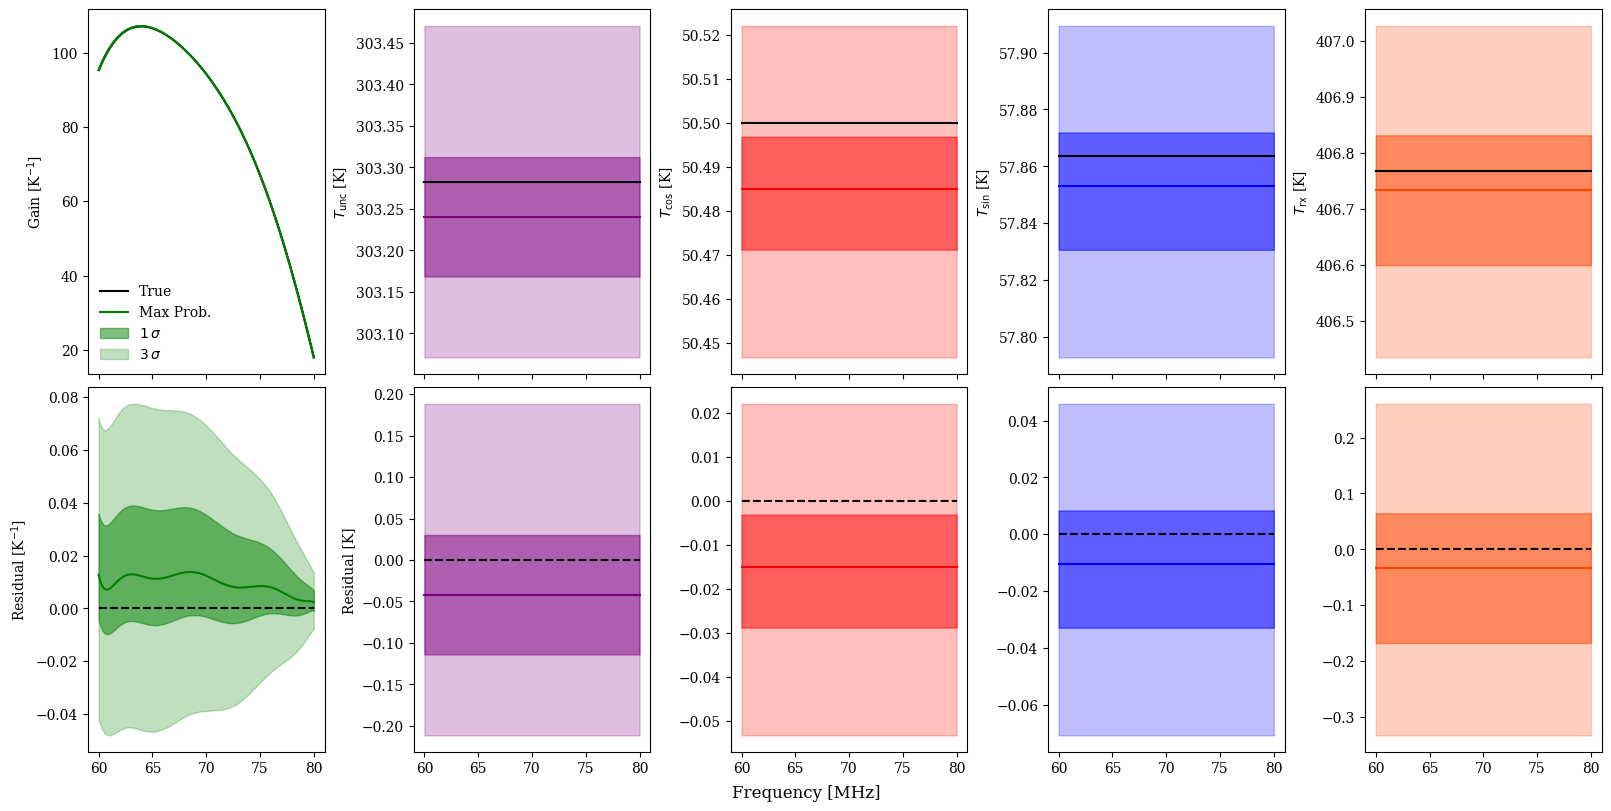

In [45]:
plot_all_1d_cal_spectra(gain_chain=param_dict['all_p_gain'],
                        unc_chain=t_unc_chains,
                        cos_chain=t_cos_chains,
                        sin_chain=t_sin_chains,
                        rx_chain=t_rx_chains,
                        gain_basis=gains_basis,
                        unc_basis=unc_basis,
                        cos_basis=cos_basis,
                        sin_basis=sin_basis,
                        rx_basis=rx_basis,
                        true_gains=gain_sim,
                        true_unc=t_unc_sim,
                        true_cos=t_cos_sim,
                        true_sin=t_sin_sim,
                        true_rx=t_rx_sim,
                        waterfall_shape=observation.data_waterfall.shape,
                        freqs=observation.freqs,
                        figsize=(16,8))

### Plotting for the spectral, time static case.

Create plots of the various 